In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', 150)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from math import log
from scipy import stats
sns.set_theme()
try:
    from cellacdc import cca_functions
    from cellacdc import myutils
except FileNotFoundError:
    # Check if user has developer version --> add the Cell_ACDC/cellacdc
    # folder to path and import from thre
    sys.path.insert(0, '../cellacdc/')
    from cellacdc import cca_functions
    from cellacdc import myutils

# ***Import nutrient switch data - original four strains*** 
# ***Import nutrient switch data - Cln3 deletions and MK strains***
# ***Import nutrient switch data - MK strains with deletions*** 
# ***Import steady state data*** 

In [2]:
# for laptop
# NS_original_4strains= pd.read_csv(r"E:\Backups\Backup 10112024\Analysed Live cell microscopy data\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
# NS_cln3dels_MKoriginals = pd.read_csv(r"E:\Backups\Backup 10112024\Analysed Live cell microscopy data\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
# NS_MKstrains_withOriginalDels = pd.read_csv(r"E:\Backups\Backup 10112024\Analysed Live cell microscopy data\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
# SS_SCDnSCGE = pd.read_csv(r"E:\Backups\Backup 10112024\Analysed Live cell microscopy data\steadystate_analysed_fornutswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")

In [3]:
# for computer
NS_original_4strains= pd.read_csv(r"Y:\Analysed Live cell microscopy data\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_cln3dels_MKoriginals = pd.read_csv(r"Y:\Analysed Live cell microscopy data\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
NS_MKstrains_withOriginalDels = pd.read_csv(r"Y:\Analysed Live cell microscopy data\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
SS_SCDnSCGE = pd.read_csv(r"Y:\Analysed Live cell microscopy data\steadystate_analysed_fornutswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\1188626664.py:2: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_original_4strains= pd.read_csv(r"Y:\Analysed Live cell microscopy data\normalnutrientswitch_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\1188626664.py:3: DtypeWarning: Columns (371) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_cln3dels_MKoriginals = pd.read_csv(r"Y:\Analysed Live cell microscopy data\Cln3delsstabs_jupyter_overall_df_with_rel_switch_and_wave_info.csv")
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\1188626664.py:4: DtypeWarning: Columns (343) have mixed types. Specify dtype option on import or set low_memory=False.
  NS_MKstrains_withOriginalDels = pd.read_csv(r"Y:\Analysed Live cell microscopy data\Cln3stabs_withMutants_jupyter_overall_df_with_rel_switch_and_wave_info.csv")


# ***update rep for MMY in the additional nutrient switch data*** 

In [4]:
#### because NS_cln3dels_MKoriginals has MMY cells with same rep, pos and Cell_ID as NS_original_4strains, edit rep column for these cells
# NS_MKstrains_withOriginalDels experiments did not have MMY 

NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 1), 'rep'] = 4
NS_cln3dels_MKoriginals.loc[(NS_cln3dels_MKoriginals['strain'] == "MMY") & (NS_cln3dels_MKoriginals['rep'] == 2), 'rep'] = 5

NS_cln3dels_MKoriginals['f_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["strain"]}_{x["position"]}_Cell_{x["Cell_ID"]}_Gen_{int(x["generation_num"])}', axis=1)
NS_cln3dels_MKoriginals['rep_str_pos_cell_id'] = NS_cln3dels_MKoriginals.apply(lambda x: f'{x["f_pos_cell_id"]}_Rep_{int(x["rep"])}', axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.drop(['f_pos_cell_id'], axis=1)
NS_cln3dels_MKoriginals = NS_cln3dels_MKoriginals.rename(columns={"rep_str_pos_cell_id": "f_pos_cell_id"})


# ***because acdc output columns changed over the years, find differences between column names of different dfs and edit them*** 

In [5]:
NS_MKstrains_withOriginalDels.drop(columns =['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',  'num_objects', 'num_objects_rel',
       'will_divide', 'will_divide_rel'], inplace = True)
#print(NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns))

In [6]:
NS_cln3dels_MKoriginals.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [7]:
NS_MKstrains_withOriginalDels.drop(columns =['bbox', 'bbox_rel', 'centroid', 'centroid_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel',
       'inertia_tensor_rel', 'label', 'label_rel', 'local_centroid',
       'local_centroid_rel', 'moments', 'moments_central',
       'moments_central_rel', 'moments_normalized', 'moments_normalized_rel',
       'moments_rel', 'time_hours', 'time_hours_rel', 'time_minutes',
       'time_minutes_rel'], inplace = True)

In [8]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index(['does_cell_die_in_this_phase', 'vol_added_since_prev_frame_fl'], dtype='object')

In [9]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [10]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index(['does_cell_die_in_this_phase'], dtype='object')

In [11]:
NS_original_4strains = NS_original_4strains.rename(columns={"vol_added_since_last_frame": "vol_added_since_prev_frame_fl"})
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"Strain": "strain"})

In [12]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Add 'does_cell_die_in_this_phase' column to the datasets that don't have it*** 

In [13]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_original_4strains['rep'].unique():
        rep_df = NS_original_4strains[NS_original_4strains['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_original_4strains = pd.concat(list_for_joining)   

In [14]:
import warnings

with warnings.catch_warnings(record=True):
    list_for_joining = []
    for rep in NS_cln3dels_MKoriginals['rep'].unique():
        rep_df = NS_cln3dels_MKoriginals[NS_cln3dels_MKoriginals['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df = rep_df[rep_df['strain'] == strain]
            for pos in (strain_df['position']).unique():
                pos_df = strain_df[strain_df["position"] == pos]
                pos_max_frame = pos_df['frame_i'].max()
                pos_min_frame = pos_df['frame_i'].min()
                for cell in (pos_df['Cell_ID']).unique():
                    cell_df = pos_df[pos_df["Cell_ID"] == cell]
                    for cycle in (cell_df['generation_num']).unique(): 
                        cycle_df = cell_df[cell_df["generation_num"] == cycle]
                        cycle_df = cycle_df.sort_values(by = 'frame_i')
                        for phase in (cycle_df['cell_cycle_stage'].unique()):
                            phase_df = cycle_df[cycle_df['cell_cycle_stage'] == phase]
                            if ((phase_df['frame_i'].min()) > pos_min_frame) & ((phase_df['frame_i'].max()) < pos_max_frame):
                                phase_df['complete_phase'] = 1
                                phase_df['does_cell_die_in_this_phase'] = 0
                            if sum(phase_df['is_cell_dead']) > 0:
                                phase_df['complete_phase'] = 0
                                phase_df['does_cell_die_in_this_phase'] = 1
                            else:
                                phase_df['does_cell_die_in_this_phase'] = 0
                            list_for_joining.append(phase_df)
    NS_cln3dels_MKoriginals = pd.concat(list_for_joining)   

In [15]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [16]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox',
       'bbox_rel', 'centroid', 'centroid_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor',
       'inertia_tensor_eigvals', 'inert

In [17]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [18]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index(['Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_mean',
       'Dia_Ph3_manualBkgr_bkgrVal_mean_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_median',
       'Dia_Ph3_manualBkgr_bkgrVal_median_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel',
       'Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
       'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel',
       'daughter_disappears_before_division',
       'daughter_disappears_before_division_rel', 'disappears_before_division',
       'disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
       'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'num_objects',
       'num_objects_rel', 'will_divide', 'will_divide_rel'],
      dtype='object')

# ***Drop columns not needed for analysis*** 

In [19]:
#drop columns we don't need
cols_to_be_dropped = ['Dia_Ph3_mean', 'Dia_Ph3_sum', 'Dia_Ph3_amount_autoBkgr', 'Dia_Ph3_amount_dataPrepBkgr', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox',
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl', 
'Dia_Ph3_median', 'Dia_Ph3_min', 'Dia_Ph3_max', 'Dia_Ph3_q25', 'Dia_Ph3_q75', 'Dia_Ph3_q05', 'Dia_Ph3_q95', 'Dia_Ph3_autoBkgr_bkgrVal_median', 
'Dia_Ph3_autoBkgr_bkgrVal_mean', 'Dia_Ph3_autoBkgr_bkgrVal_q75', 'Dia_Ph3_autoBkgr_bkgrVal_q25', 'Dia_Ph3_autoBkgr_bkgrVal_q95', 'Dia_Ph3_autoBkgr_bkgrVal_q05', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_median', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q75', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25', 
'Dia_Ph3_dataPrepBkgr_bkgrVal_q95', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05', 'Dia_Ph3_CV', 'major_axis_length_gui', 'minor_axis_length_gui', 'inertia_tensor_eigvals-0', 
'inertia_tensor_eigvals-1', 'equivalent_diameter', 'moments-0-0', 'moments-0-1', 'moments-0-2', 'moments-0-3', 'moments-1-0', 'moments-1-1', 'moments-1-2',
'moments-1-3', 'moments-2-0', 'moments-2-1', 'moments-2-2', 'moments-2-3', 'moments-3-0', 'moments-3-1', 'moments-3-2', 'moments-3-3', 'area_gui', 'solidity_gui', 
'extent', 'inertia_tensor-0-0', 'inertia_tensor-0-1', 'inertia_tensor-1-0', 'inertia_tensor-1-1', 'filled_area_gui', 'centroid-0', 'centroid-1', 'bbox_area',
'local_centroid-0', 'local_centroid-1', 'convex_area_gui', 'euler_number', 'moments_normalized-0-0', 'moments_normalized-0-1', 'moments_normalized-0-2',
'moments_normalized-0-3', 'moments_normalized-1-0', 'moments_normalized-1-1', 'moments_normalized-1-2', 'moments_normalized-1-3', 'moments_normalized-2-0',
'moments_normalized-2-1', 'moments_normalized-2-2', 'moments_normalized-2-3', 'moments_normalized-3-0', 'moments_normalized-3-1', 'moments_normalized-3-2',
'moments_normalized-3-3', 'moments_central-0-0', 'moments_central-0-1', 'moments_central-0-2', 'moments_central-0-3', 'moments_central-1-0', 'moments_central-1-1',
'moments_central-1-2', 'moments_central-1-3', 'moments_central-2-0', 'moments_central-2-1', 'moments_central-2-2', 'moments_central-2-3', 'moments_central-3-0',
'moments_central-3-1', 'moments_central-3-2', 'moments_central-3-3', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'area', 'convex_area', 'filled_area', 'major_axis_length','minor_axis_length', 'orientation', 'perimeter', 'centroid_y', 'centroid_x', 'solidity','velocity_pixel', 'velocity_um','Dia_Ph3_mean_rel', 'Dia_Ph3_sum_rel','Dia_Ph3_amount_autoBkgr_rel', 'Dia_Ph3_amount_dataPrepBkgr_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_vox_rel', 
'Dia_Ph3_concentration_dataPrepBkgr_from_vol_vox_rel', 'Dia_Ph3_concentration_autoBkgr_from_vol_fl_rel', 'Dia_Ph3_concentration_dataPrepBkgr_from_vol_fl_rel', 
'Dia_Ph3_median_rel', 'Dia_Ph3_min_rel', 'Dia_Ph3_max_rel', 'Dia_Ph3_q25_rel', 'Dia_Ph3_q75_rel', 'Dia_Ph3_q05_rel', 'Dia_Ph3_q95_rel',
'Dia_Ph3_autoBkgr_bkgrVal_median_rel', 'Dia_Ph3_autoBkgr_bkgrVal_mean_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q75_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q25_rel',
'Dia_Ph3_autoBkgr_bkgrVal_q95_rel', 'Dia_Ph3_autoBkgr_bkgrVal_q05_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_median_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_mean_rel',
'Dia_Ph3_dataPrepBkgr_bkgrVal_q75_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q25_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q95_rel', 'Dia_Ph3_dataPrepBkgr_bkgrVal_q05_rel', 
'Dia_Ph3_CV_rel', 'major_axis_length_gui_rel', 'minor_axis_length_gui_rel', 'inertia_tensor_eigvals-0_rel', 'inertia_tensor_eigvals-1_rel', 'equivalent_diameter_rel','moments-0-0_rel', 'moments-0-1_rel', 'moments-0-2_rel', 'moments-0-3_rel', 'moments-1-0_rel', 'moments-1-1_rel', 'moments-1-2_rel', 'moments-1-3_rel', 'moments-2-0_rel', 'moments-2-1_rel', 'moments-2-2_rel', 'moments-2-3_rel', 'moments-3-0_rel', 'moments-3-1_rel', 'moments-3-2_rel', 'moments-3-3_rel','area_gui_rel', 'solidity_gui_rel', 'extent_rel', 'inertia_tensor-0-0_rel', 'inertia_tensor-0-1_rel', 'inertia_tensor-1-0_rel', 'inertia_tensor-1-1_rel','filled_area_gui_rel', 'centroid-0_rel', 'centroid-1_rel', 'bbox_area_rel', 'local_centroid-0_rel', 'local_centroid-1_rel', 'convex_area_gui_rel', 'euler_number_rel', 'moments_normalized-0-0_rel', 'moments_normalized-0-1_rel', 'moments_normalized-0-2_rel', 'moments_normalized-0-3_rel', 
'moments_normalized-1-0_rel', 'moments_normalized-1-1_rel', 'moments_normalized-1-2_rel', 'moments_normalized-1-3_rel', 'moments_normalized-2-0_rel',
'moments_normalized-2-1_rel', 'moments_normalized-2-2_rel', 'moments_normalized-2-3_rel', 'moments_normalized-3-0_rel', 'moments_normalized-3-1_rel', 
'moments_normalized-3-2_rel', 'moments_normalized-3-3_rel', 'moments_central-0-0_rel', 'moments_central-0-1_rel', 'moments_central-0-2_rel', 
'moments_central-0-3_rel', 'moments_central-1-0_rel', 'moments_central-1-1_rel', 'moments_central-1-2_rel', 'moments_central-1-3_rel', 'moments_central-2-0_rel',
'moments_central-2-1_rel', 'moments_central-2-2_rel', 'moments_central-2-3_rel', 'moments_central-3-0_rel', 'moments_central-3-1_rel', 'moments_central-3-2_rel',
'moments_central-3-3_rel', 'bbox-0_rel', 'bbox-1_rel', 'bbox-2_rel', 'bbox-3_rel', 'area_rel', 'convex_area_rel', 'filled_area_rel', 'major_axis_length_rel', 
'minor_axis_length_rel', 'orientation_rel', 'perimeter_rel', 'centroid_y_rel', 'centroid_x_rel', 'solidity_rel', 'velocity_pixel_rel', 'velocity_um_rel',
'phase_Dia_Ph3_amount_at_beginning', 'phase_Dia_Ph3_mean_at_beginning', 'phase_Dia_Ph3_concentration_at_beginning', 'phase_Dia_Ph3_concentration_at_end', 
'phase_Dia_Ph3_combined_amount_at_beginning', 'phase_Dia_Ph3_combined_amount_at_end', 'Dia_Ph3_amount_manualBkgr', 'Dia_Ph3_amount_manualBkgr_rel',
'Dia_Ph3_manualBkgr_bkgrVal_mean','Dia_Ph3_manualBkgr_bkgrVal_mean_rel','Dia_Ph3_manualBkgr_bkgrVal_median','Dia_Ph3_manualBkgr_bkgrVal_median_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q05', 'Dia_Ph3_manualBkgr_bkgrVal_q05_rel','Dia_Ph3_manualBkgr_bkgrVal_q25', 'Dia_Ph3_manualBkgr_bkgrVal_q25_rel',
'Dia_Ph3_manualBkgr_bkgrVal_q75', 'Dia_Ph3_manualBkgr_bkgrVal_q75_rel','Dia_Ph3_manualBkgr_bkgrVal_q95', 'Dia_Ph3_manualBkgr_bkgrVal_q95_rel',
'Dia_Ph3_mean_manualBkgr', 'Dia_Ph3_mean_manualBkgr_rel', 'bbox','bbox_rel', 'centroid', 'centroid_rel','daughter_disappears_before_division',
'daughter_disappears_before_division_rel', 'disappears_before_division','disappears_before_division_rel', 'end_of_cell_cycle_frame_i',
'end_of_cell_cycle_frame_i_rel', 'index', 'index_rel', 'inertia_tensor','inertia_tensor_eigvals', 'inertia_tensor_eigvals_rel','inertia_tensor_rel', 'label', 'label_rel', 'local_centroid','local_centroid_rel', 'moments', 'moments_central','moments_central_rel','moments_normalized','moments_normalized_rel','moments_rel', 'num_objects', 'num_objects_rel', 'time_hours','time_hours_rel', 'time_minutes', 'time_minutes_rel', 'will_divide','will_divide_rel']

NS_original_4strains.drop(columns=[col for col in NS_original_4strains if col in cols_to_be_dropped], inplace=True)
NS_cln3dels_MKoriginals.drop(columns=[col for col in NS_cln3dels_MKoriginals if col in cols_to_be_dropped], inplace=True)
NS_MKstrains_withOriginalDels.drop(columns=[col for col in NS_MKstrains_withOriginalDels if col in cols_to_be_dropped], inplace=True)
SS_SCDnSCGE.drop(columns=[col for col in SS_SCDnSCGE if col in cols_to_be_dropped], inplace=True)



In [20]:
print(NS_original_4strains.shape)
print(NS_cln3dels_MKoriginals.shape)
print(NS_MKstrains_withOriginalDels.shape)
print(SS_SCDnSCGE.shape)

NS_original_4strains['experiment_type'] = "nutrient_switch"
NS_cln3dels_MKoriginals['experiment_type'] = "nutrient_switch"
NS_MKstrains_withOriginalDels['experiment_type'] = "nutrient_switch"
SS_SCDnSCGE['experiment_type'] = "steady state"


(482563, 114)
(366669, 114)
(388955, 114)
(366878, 61)


In [21]:
NS_MKstrains_withOriginalDels.columns.difference(NS_original_4strains.columns)

Index([], dtype='object')

In [22]:
NS_original_4strains.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

In [23]:
NS_MKstrains_withOriginalDels.columns.difference(NS_cln3dels_MKoriginals.columns)

Index([], dtype='object')

In [24]:
NS_cln3dels_MKoriginals.columns.difference(NS_MKstrains_withOriginalDels.columns)

Index([], dtype='object')

# ***All the nutrient-switch dfs have the same columns now. Steady-state dfs were dataprepped with a different script before acdc downstream notebook was published, so they have very different columns.*** 

In [25]:
SS_SCDnSCGE = SS_SCDnSCGE.rename(columns={"date": "rep", "Position": "position"})
SS_SCD = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCD"]
SS_SCGE = SS_SCDnSCGE[SS_SCDnSCGE['growthmedium'] == "SCGE"]

# ***Check strain names and make them uniform between dfs*** 

In [26]:
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())
NS_MKstrains_withOriginalDels['strain'] = np.where(NS_MKstrains_withOriginalDels['strain'] == "MK40", "MK_40", NS_MKstrains_withOriginalDels['strain'])
print(NS_original_4strains.strain.unique())
print(NS_cln3dels_MKoriginals.strain.unique())
print(NS_MKstrains_withOriginalDels.strain.unique())
print(SS_SCDnSCGE.strain.unique())

['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD']
['MMY' 'CLN3DEL' 'CLN3_WHI5_DD' 'CLN3_WHI5_BCK2_TD' 'MK_40' 'MK_41'
 'MK_44']
['MK_40' 'YCY027_1_bck2delMK40bg' 'YCY031_4_whi5delMK40bg'
 'YCY034_1_doubledelMK40bg' 'MK_44' 'YCY029_3_bck2delMK44bg'
 'YCY033_2_whi5delMK44bg' 'YCY036_1_doubledelMK44bg']
['MMY' 'BCK2DEL' 'WHI5DEL' 'WHI5_BCK2_DD' 'WHI5_CCR4_DD' 'CCR4DEL']


# ***Concatenate all nutrient switch dfs into one*** 

In [27]:
overall_df_with_rel_and_switch_info = pd.concat([NS_original_4strains, NS_cln3dels_MKoriginals, NS_MKstrains_withOriginalDels]).reset_index(drop = True)

# print(NS_original_4strains.shape)
# print(NS_cln3dels_MKoriginals.shape)
# print(NS_MKstrains_withOriginalDels.shape)
# overall_df_with_rel_and_switch_info.shape 

# ***Revision1: Bootstrapping permutations of positions and calculating frame-specific CVs for every permutation.*** 
# ***including all positions*** 

In [28]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
# display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))
chosen_strains_df = select_strains_df[(select_strains_df["is_cell_dead"] == 0) & (select_strains_df["relationship"] == "mother")]
chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)
# chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
#                          (chosen_strains_df['position'] == "Position_38") & 
#                          (chosen_strains_df['rep'] == 2)
#                          ].index)
# chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
#                          (chosen_strains_df['position'] == "Position_5") & 
#                          (chosen_strains_df['rep'] == 2)
#                          ].index)
#display(chosen_strains_df.head(30))

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3434976119.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)


In [29]:
# STRATEGY:
# bootstrap position names within strains (10000 iterations)
# calculate frame-specific CVs with new position combination for every frame for every iteration
# plot frame-specific CVs as a lineplot
# check for significance using CI of differences between bootstrapped CVs of strains as per:
# https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.



In [30]:
# pip install statsmodels

In [31]:
from sklearn.utils import resample
import statsmodels.stats.api as sms


seed = 42
n_iterations = 1000
bootstrapped_frame_specific_cv_list = []


for strain in chosen_strains_df.strain.unique():
    strain_df = chosen_strains_df[chosen_strains_df['strain'] == strain]
    pos_list = np.array(strain_df.unique_pos_rep_id.unique())
    display(strain, len(pos_list))
    for i in range(n_iterations):
        pos_list_resampled = resample(pos_list, replace=True, random_state = seed+i)
        iter_df = pd.concat([strain_df[strain_df['unique_pos_rep_id'].eq(x)] for x in pos_list_resampled],ignore_index=True)
        if i == 1:
            #display(iter_df.head(50))
            display(pos_list_resampled)
            display(len(pos_list_resampled))
        for frame in iter_df.frame_i.unique():
            frame_df = iter_df[iter_df['frame_i'] == frame]
            bs_mean_vol_frame = (frame_df["combined_mother_bud_volume"]).mean()
            bs_stdev_vol_frame = np.std(frame_df["combined_mother_bud_volume"])
            bs_CV_sys_vol_frame = bs_stdev_vol_frame/bs_mean_vol_frame
            n_cells_frame = len(frame_df.f_pos_cell_id.unique())
            info = {'strain': strain, 
                    'iteration': i,
                    'pos_list': pos_list_resampled,
                    'frame_i': frame,
                    'bs_mean_vol_frame': bs_mean_vol_frame, 
                    'bs_stdev_vol_frame': bs_stdev_vol_frame, 
                    'bs_CV_sys_vol_frame': bs_CV_sys_vol_frame, 
                    'n_cells_frame': n_cells_frame
                    }
            bootstrapped_frame_specific_cv_list.append(info)
            
                
bootstrapped_cv_df = pd.DataFrame.from_dict(bootstrapped_frame_specific_cv_list)
bootstrapped_cv_df.sort_values(by =['strain', 'iteration', 'frame_i'], inplace = True)
display(bootstrapped_cv_df.head(10))



'MMY'

39

array(['Position_5_Rep_1', 'Position_1_Rep_1', 'Position_5_Rep_3',
       'Position_8_Rep_2', 'Position_9_Rep_2', 'Position_1_Rep_4',
       'Position_3_Rep_1', 'Position_4_Rep_4', 'Position_7_Rep_3',
       'Position_1_Rep_1', 'Position_3_Rep_5', 'Position_3_Rep_2',
       'Position_9_Rep_3', 'Position_2_Rep_1', 'Position_2_Rep_5',
       'Position_3_Rep_2', 'Position_3_Rep_1', 'Position_3_Rep_5',
       'Position_5_Rep_1', 'Position_4_Rep_5', 'Position_4_Rep_2',
       'Position_8_Rep_3', 'Position_6_Rep_4', 'Position_2_Rep_2',
       'Position_1_Rep_2', 'Position_2_Rep_5', 'Position_5_Rep_1',
       'Position_2_Rep_4', 'Position_1_Rep_2', 'Position_8_Rep_1',
       'Position_4_Rep_3', 'Position_6_Rep_4', 'Position_4_Rep_1',
       'Position_2_Rep_5', 'Position_9_Rep_3', 'Position_3_Rep_4',
       'Position_10_Rep_3', 'Position_5_Rep_3', 'Position_5_Rep_3'],
      dtype=object)

39

'WHI5_BCK2_DD'

29

array(['Position_33_Rep_1', 'Position_29_Rep_1', 'Position_36_Rep_2',
       'Position_33_Rep_3', 'Position_38_Rep_3', 'Position_34_Rep_2',
       'Position_31_Rep_3', 'Position_36_Rep_2', 'Position_39_Rep_3',
       'Position_39_Rep_3', 'Position_31_Rep_1', 'Position_32_Rep_2',
       'Position_35_Rep_3', 'Position_29_Rep_1', 'Position_32_Rep_1',
       'Position_37_Rep_2', 'Position_39_Rep_3', 'Position_40_Rep_1',
       'Position_37_Rep_3', 'Position_30_Rep_1', 'Position_33_Rep_2',
       'Position_31_Rep_1', 'Position_40_Rep_1', 'Position_31_Rep_1',
       'Position_32_Rep_1', 'Position_33_Rep_3', 'Position_33_Rep_1',
       'Position_33_Rep_1', 'Position_34_Rep_2'], dtype=object)

29

,strain,iteration,pos_list,frame_i,bs_mean_vol_frame,bs_stdev_vol_frame,bs_CV_sys_vol_frame,n_cells_frame
0,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",0,106.976986,61.424585,0.574185,98
1,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",1,104.701456,62.167065,0.593755,103
2,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",2,105.853286,63.346008,0.598432,105
3,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",3,104.137346,63.703941,0.611730,108
4,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",4,105.212951,63.055073,0.599309,109
5,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",5,104.119863,64.527458,0.619742,112
6,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",6,103.285445,65.404993,0.633245,115
7,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",7,104.248113,64.937984,0.622918,116
8,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",8,105.848095,65.525276,0.619050,117
9,MMY,0,"[Position_6_Rep_5, Position_2_Rep_4, Position_6_Rep_2, Position_8_Rep_1, Position_4_Rep_3, Position_6_Rep_5, Position_1_Rep_3, Position_6_Rep_3, P...",9,103.580851,64.379429,0.621538,121


In [32]:
bootstrapped_cv_df['frame_rel_to_nutrient_switch'] = bootstrapped_cv_df['frame_i'] - 50
bootstrapped_cv_df['time_rel_to_nutrient_switch_hours'] = (bootstrapped_cv_df['frame_rel_to_nutrient_switch']*3)/60

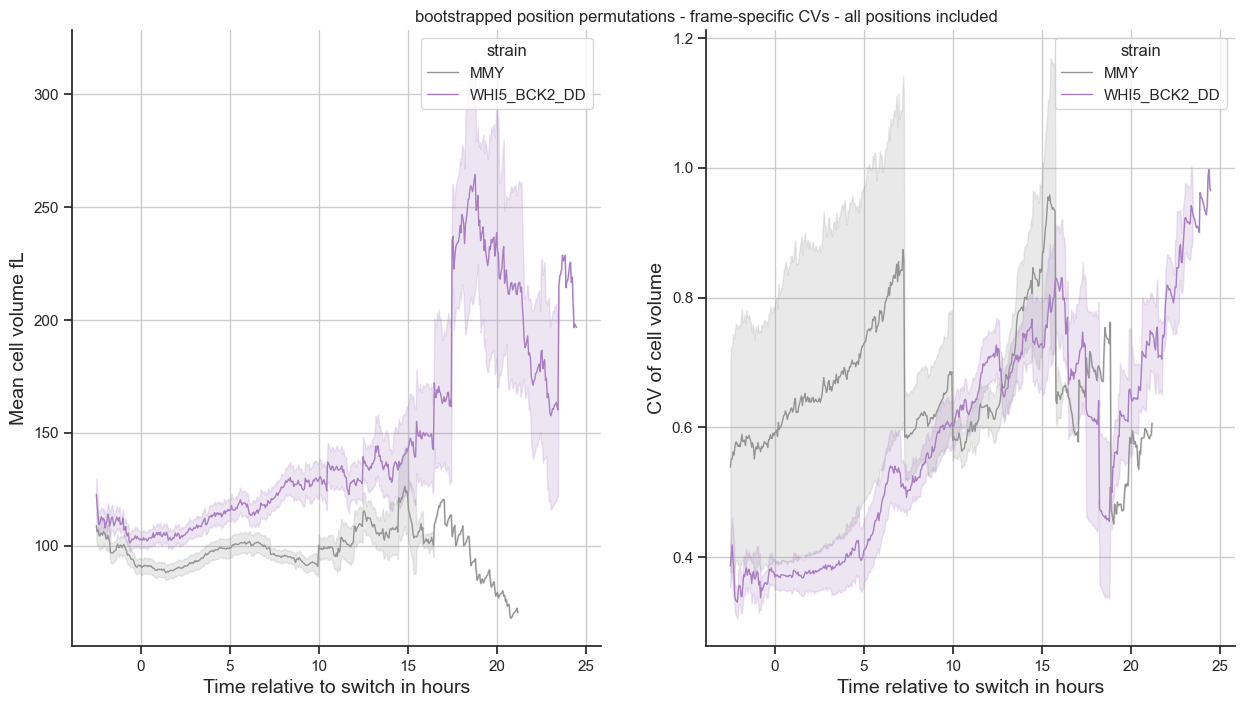

In [33]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 

sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(15, 8) )
S = sns.lineplot(data = bootstrapped_cv_df,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="bs_mean_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="bs_CV_sys_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )

S.set_title("bootstrapped position permutations - frame-specific CVs - all positions included", fontsize = 12, x= 0)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
sns.despine(ax = ax1)
sns.despine(ax = ax2)
plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\bs_post_switch_CVs_allpos_computer.png')
plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\bs_post_switch_CVs_allpos_computer.svg')

In [34]:
# plot sd instead of ci

# ***Revision1: Bootstrapping permutations of positions and calculating frame-specific CVs for every permutation.*** 
# ***excluding one outlier position*** 

In [37]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
# display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))
chosen_strains_df = select_strains_df[(select_strains_df["is_cell_dead"] == 0) & (select_strains_df["relationship"] == "mother")]
chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)
# chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
#                          (chosen_strains_df['position'] == "Position_3") & 
#                          (chosen_strains_df['rep'] == 4)
#                          ].index)
chosen_strains_df = chosen_strains_df.drop(chosen_strains_df[
                         (chosen_strains_df['position'] == "Position_5") & 
                         (chosen_strains_df['rep'] == 2)
                         ].index)
#display(chosen_strains_df.head(30))

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\1626603651.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chosen_strains_df['unique_pos_rep_id'] = chosen_strains_df.apply(lambda x: f'{x["position"]}_Rep_{int(x["rep"])}', axis=1)


In [38]:
# STRATEGY:
# bootstrap position names within strains (10000 iterations)
# calculate frame-specific CVs with new position combination for every frame for every iteration
# plot frame-specific CVs as a lineplot
# check for significance using CI of differences between bootstrapped CVs of strains as per:
# https://stats.stackexchange.com/questions/610134/t-test-on-bootstrapped-estimates#:~:text=The%20bootstrap%20is%20a%20valid,also%20available%20as%20an%20alternative.



In [39]:
# pip install statsmodels

In [40]:
from sklearn.utils import resample
import statsmodels.stats.api as sms


seed = 42
n_iterations = 1000
bootstrapped_frame_specific_cv_list = []


for strain in chosen_strains_df.strain.unique():
    strain_df = chosen_strains_df[chosen_strains_df['strain'] == strain]
    pos_list = np.array(strain_df.unique_pos_rep_id.unique())
    display(strain, len(pos_list))
    for i in range(n_iterations):
        pos_list_resampled = resample(pos_list, replace=True, random_state = seed+i)
        iter_df = pd.concat([strain_df[strain_df['unique_pos_rep_id'].eq(x)] for x in pos_list_resampled],ignore_index=True)
        if i == 1:
            #display(iter_df.head(50))
            display(pos_list_resampled)
            display(len(pos_list_resampled))
        for frame in iter_df.frame_i.unique():
            frame_df = iter_df[iter_df['frame_i'] == frame]
            bs_mean_vol_frame = (frame_df["combined_mother_bud_volume"]).mean()
            bs_stdev_vol_frame = np.std(frame_df["combined_mother_bud_volume"])
            bs_CV_sys_vol_frame = bs_stdev_vol_frame/bs_mean_vol_frame
            n_cells_frame = len(frame_df.f_pos_cell_id.unique())
            info = {'strain': strain, 
                    'iteration': i,
                    'pos_list': pos_list_resampled,
                    'frame_i': frame,
                    'bs_mean_vol_frame': bs_mean_vol_frame, 
                    'bs_stdev_vol_frame': bs_stdev_vol_frame, 
                    'bs_CV_sys_vol_frame': bs_CV_sys_vol_frame, 
                    'n_cells_frame': n_cells_frame
                    }
            bootstrapped_frame_specific_cv_list.append(info)
            
                
bootstrapped_cv_df = pd.DataFrame.from_dict(bootstrapped_frame_specific_cv_list)
bootstrapped_cv_df.sort_values(by =['strain', 'iteration', 'frame_i'], inplace = True)
display(bootstrapped_cv_df.head(10))



'MMY'

38

array(['Position_5_Rep_1', 'Position_1_Rep_1', 'Position_6_Rep_3',
       'Position_9_Rep_2', 'Position_1_Rep_3', 'Position_2_Rep_4',
       'Position_3_Rep_1', 'Position_5_Rep_4', 'Position_8_Rep_3',
       'Position_1_Rep_1', 'Position_4_Rep_5', 'Position_3_Rep_2',
       'Position_10_Rep_3', 'Position_2_Rep_1', 'Position_3_Rep_5',
       'Position_3_Rep_2', 'Position_3_Rep_1', 'Position_4_Rep_5',
       'Position_5_Rep_1', 'Position_5_Rep_5', 'Position_4_Rep_2',
       'Position_9_Rep_3', 'Position_1_Rep_5', 'Position_2_Rep_2',
       'Position_1_Rep_2', 'Position_3_Rep_5', 'Position_5_Rep_1',
       'Position_3_Rep_4', 'Position_1_Rep_2', 'Position_8_Rep_1',
       'Position_5_Rep_3', 'Position_1_Rep_5', 'Position_4_Rep_1',
       'Position_3_Rep_5', 'Position_10_Rep_3', 'Position_4_Rep_4',
       'Position_1_Rep_4', 'Position_6_Rep_3'], dtype=object)

38

'WHI5_BCK2_DD'

29

array(['Position_33_Rep_1', 'Position_29_Rep_1', 'Position_36_Rep_2',
       'Position_33_Rep_3', 'Position_38_Rep_3', 'Position_34_Rep_2',
       'Position_31_Rep_3', 'Position_36_Rep_2', 'Position_39_Rep_3',
       'Position_39_Rep_3', 'Position_31_Rep_1', 'Position_32_Rep_2',
       'Position_35_Rep_3', 'Position_29_Rep_1', 'Position_32_Rep_1',
       'Position_37_Rep_2', 'Position_39_Rep_3', 'Position_40_Rep_1',
       'Position_37_Rep_3', 'Position_30_Rep_1', 'Position_33_Rep_2',
       'Position_31_Rep_1', 'Position_40_Rep_1', 'Position_31_Rep_1',
       'Position_32_Rep_1', 'Position_33_Rep_3', 'Position_33_Rep_1',
       'Position_33_Rep_1', 'Position_34_Rep_2'], dtype=object)

29

,strain,iteration,pos_list,frame_i,bs_mean_vol_frame,bs_stdev_vol_frame,bs_CV_sys_vol_frame,n_cells_frame
0,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",0,98.645235,32.016981,0.324567,102
1,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",1,96.597090,31.684813,0.328010,106
2,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",2,98.278344,33.136665,0.337172,107
3,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",3,97.746906,32.499474,0.332486,110
4,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",4,97.418873,31.992604,0.328403,113
5,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",5,98.839225,33.085680,0.334742,115
6,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",6,97.108069,33.954377,0.349656,118
7,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",7,97.834769,34.303484,0.350627,120
8,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",8,99.452599,34.324167,0.345131,121
9,MMY,0,"[Position_3_Rep_4, Position_7_Rep_2, Position_8_Rep_1, Position_5_Rep_3, Position_2_Rep_3, Position_7_Rep_3, Position_2_Rep_2, Position_2_Rep_2, P...",9,98.292297,33.356179,0.339357,125


In [41]:
bootstrapped_cv_df['frame_rel_to_nutrient_switch'] = bootstrapped_cv_df['frame_i'] - 50
bootstrapped_cv_df['time_rel_to_nutrient_switch_hours'] = (bootstrapped_cv_df['frame_rel_to_nutrient_switch']*3)/60

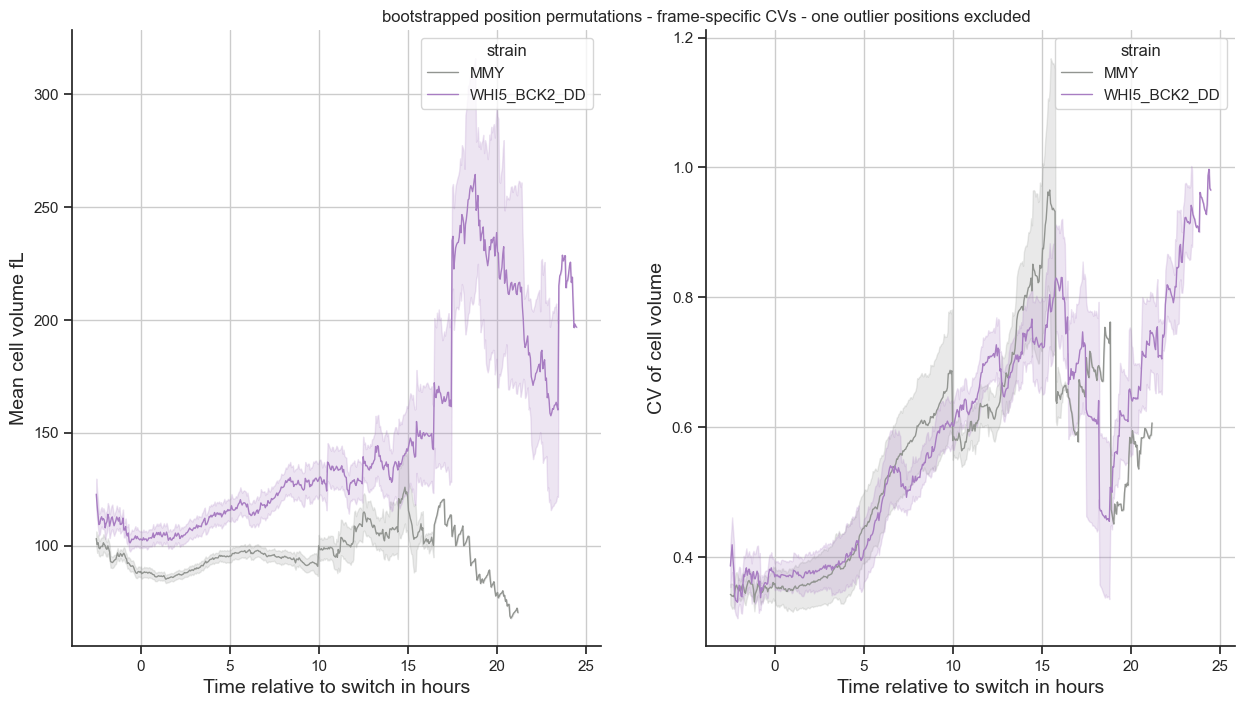

In [42]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 

sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(15, 8) )
S = sns.lineplot(data = bootstrapped_cv_df,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="bs_mean_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="bs_CV_sys_vol_frame", 
                hue = "strain", 
                errorbar = "sd",
                palette = palette
                   )

S.set_title("bootstrapped position permutations - frame-specific CVs - one outlier positions excluded", fontsize = 12, x= 0)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
sns.despine(ax = ax1)
sns.despine(ax = ax2)
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\bs_post_switch_CVs_excludingrep2pos5_computer.png")
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\bs_post_switch_CVs_excludingrep2pos5_computer.svg")

# ***not used -Revision1: For every frame, bootstrapping permutations of positions and calculating frame-specific CVs.*** 

In [35]:
from sklearn.utils import resample
import statsmodels.stats.api as sms


seed = 42
n_iterations = 100
bootstrapped_frame_specific_cv_list = []


for strain in chosen_strains_df.strain.unique():
    strain_df = chosen_strains_df[chosen_strains_df['strain'] == strain]
    for frame in strain_df.frame_i.unique():
        frame_df = strain_df[strain_df['frame_i'] == frame]
        pos_list = np.array(frame_df.unique_pos_rep_id.unique())
        #display(strain, len(pos_list))
        for i in range(n_iterations):
            pos_list_resampled = resample(pos_list, replace=True, random_state = seed+i)
            
            iter_df = pd.concat([frame_df[frame_df['unique_pos_rep_id'].eq(x)] for x in pos_list_resampled],ignore_index=True)
            #if i == 1:
                #display(iter_df.head(50))
                #display(pos_list_resampled)
                #display(len(pos_list_resampled))
            
            bs_mean_vol_frame = (iter_df["combined_mother_bud_volume"]).mean()
            bs_stdev_vol_frame = np.std(iter_df["combined_mother_bud_volume"])
            bs_CV_sys_vol_frame = bs_stdev_vol_frame/bs_mean_vol_frame
            info = {'strain': strain, 
                    'frame_i': frame,
                    'iteration': i,
                    'pos_list': pos_list_resampled,
                    'bs_mean_vol_frame': bs_mean_vol_frame, 
                    'bs_stdev_vol_frame': bs_stdev_vol_frame, 
                    'bs_CV_sys_vol_frame': bs_CV_sys_vol_frame, 
                    }
            bootstrapped_frame_specific_cv_list.append(info)
                
                
bootstrapped_cv_df = pd.DataFrame.from_dict(bootstrapped_frame_specific_cv_list)
bootstrapped_cv_df.sort_values(by =['strain', 'iteration', 'frame_i'], inplace = True)
display(bootstrapped_cv_df.head(10))



KeyboardInterrupt: 

In [ ]:
bootstrapped_cv_df['frame_rel_to_nutrient_switch'] = bootstrapped_cv_df['frame_i'] - 50
bootstrapped_cv_df['time_rel_to_nutrient_switch_hours'] = (bootstrapped_cv_df['frame_rel_to_nutrient_switch']*3)/60

In [ ]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2)) = plt.subplots(nrows=1, ncols=2, sharex= True, sharey= False, figsize=(15, 8) )
S = sns.lineplot(data = bootstrapped_cv_df,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="bs_mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = bootstrapped_cv_df,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="bs_CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )

S.set_title("bootstrapped position permutations - frame-specific CVs", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)

#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\bs_post_switch_CVs_microscopy')

# ***only used for n_cells plot - Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions for every frame with all positions*** 

In [43]:
display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))

['Unnamed: 0',
 'frame_i',
 'time_seconds',
 'Cell_ID',
 'is_cell_dead',
 'is_cell_excluded',
 'x_centroid',
 'y_centroid',
 'was_manually_edited',
 'cell_cycle_stage',
 'generation_num',
 'relative_ID',
 'relationship',
 'emerg_frame_i',
 'division_frame_i',
 'is_history_known',
 'corrected_assignment',
 'cell_area_pxl',
 'cell_area_um2',
 'cell_vol_vox',
 'cell_vol_fl',
 'cell_vol_vox_downstream',
 'cell_vol_fl_downstream',
 '2d_label_count',
 'min_t',
 'max_t',
 'lifespan',
 'age',
 'frames_till_gone',
 'elongation',
 'Dia_Ph3_corrected_mean',
 'Dia_Ph3_raw_sum',
 'Dia_Ph3_corrected_amount',
 'Dia_Ph3_corrected_concentration',
 'max_frame_pos',
 'file',
 'selection_subset',
 'position',
 'directory',
 'time_seconds_rel',
 'Cell_ID_rel',
 'is_cell_dead_rel',
 'is_cell_excluded_rel',
 'x_centroid_rel',
 'y_centroid_rel',
 'was_manually_edited_rel',
 'cell_cycle_stage_rel',
 'generation_num_rel',
 'relative_ID_rel',
 'relationship_rel',
 'emerg_frame_i_rel',
 'division_frame_i_rel',
 '

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,cell_vol_fl_rel,combined_mother_bud_volume,f_pos_cell_id
0,0,1,0,S,135.471216,72.948291,208.419507,MMY_Position_1_Cell_1_Gen_2_Rep_1
1,1,1,0,S,131.569655,73.392645,204.962300,MMY_Position_1_Cell_1_Gen_2_Rep_1
2,2,1,0,G1,135.354415,76.026385,135.354415,MMY_Position_1_Cell_1_Gen_3_Rep_1
3,3,1,0,G1,136.988988,77.240173,136.988988,MMY_Position_1_Cell_1_Gen_3_Rep_1
4,4,1,0,G1,131.651731,76.639812,131.651731,MMY_Position_1_Cell_1_Gen_3_Rep_1
5,5,1,0,G1,131.117833,78.965256,131.117833,MMY_Position_1_Cell_1_Gen_3_Rep_1
6,6,1,0,G1,131.318354,82.143631,131.318354,MMY_Position_1_Cell_1_Gen_3_Rep_1
7,7,1,0,S,133.295539,0.881806,134.177345,MMY_Position_1_Cell_1_Gen_3_Rep_1
8,8,1,0,S,130.114343,2.567045,132.681388,MMY_Position_1_Cell_1_Gen_3_Rep_1
9,9,1,0,S,130.534535,3.559139,134.093674,MMY_Position_1_Cell_1_Gen_3_Rep_1


In [44]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
# nobud_df = nobud_df.drop(nobud_df[
#                          (nobud_df['position'] == "Position_3") & 
#                          (nobud_df['rep'] == 4)
#                          ].index)
# nobud_df = nobud_df.drop(nobud_df[
#                          (nobud_df['position'] == "Position_5") & 
#                          (nobud_df['rep'] == 2)
#                          ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [45]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            #& (select_strains_df['cell_cycle_stage'] == "G1")
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,...,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,...,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,100.058842,61.854682,0.618183,269
500,110813,30,5400.0,2,0,0,521,459,0,G1,...,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,111.872760,42.725300,0.381910,121


100.05884162686417

In [46]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

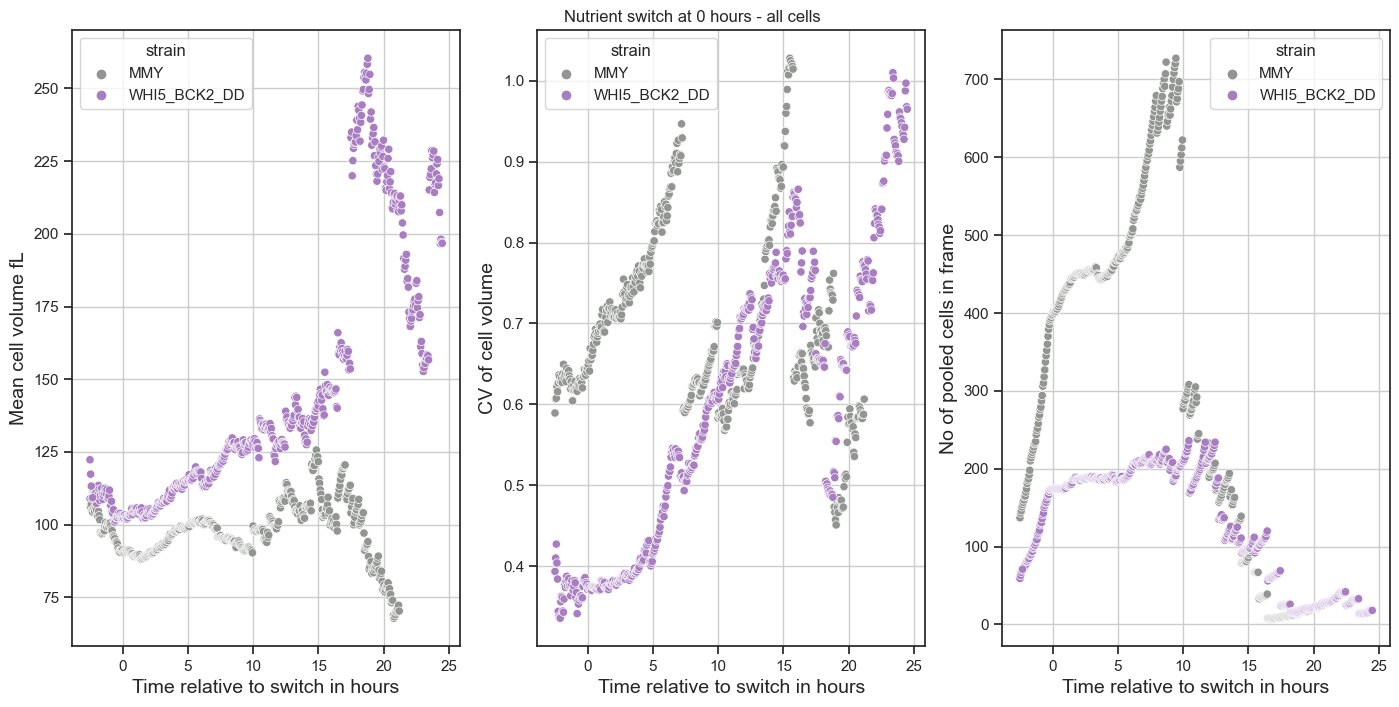

In [47]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

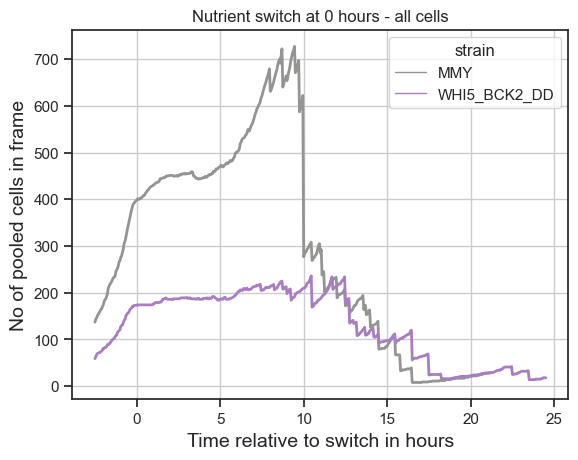

In [48]:
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours',
                y= "n_cells_in_frame_pooled", 
                hue = "strain", 
                linewidth = 2,
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells", fontsize = 12)
S.set_xlabel("Time relative to switch in hours", fontsize = 14)
S.set_ylabel("No of pooled cells in frame", fontsize = 14)
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_pooled_cell_no_per_frame_all_pos_computer.png")
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_pooled_cell_no_per_frame_all_pos_computer.svg")

In [49]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1) & (select_strains_df["cell_cycle_stage"] == "G1")]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [42]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

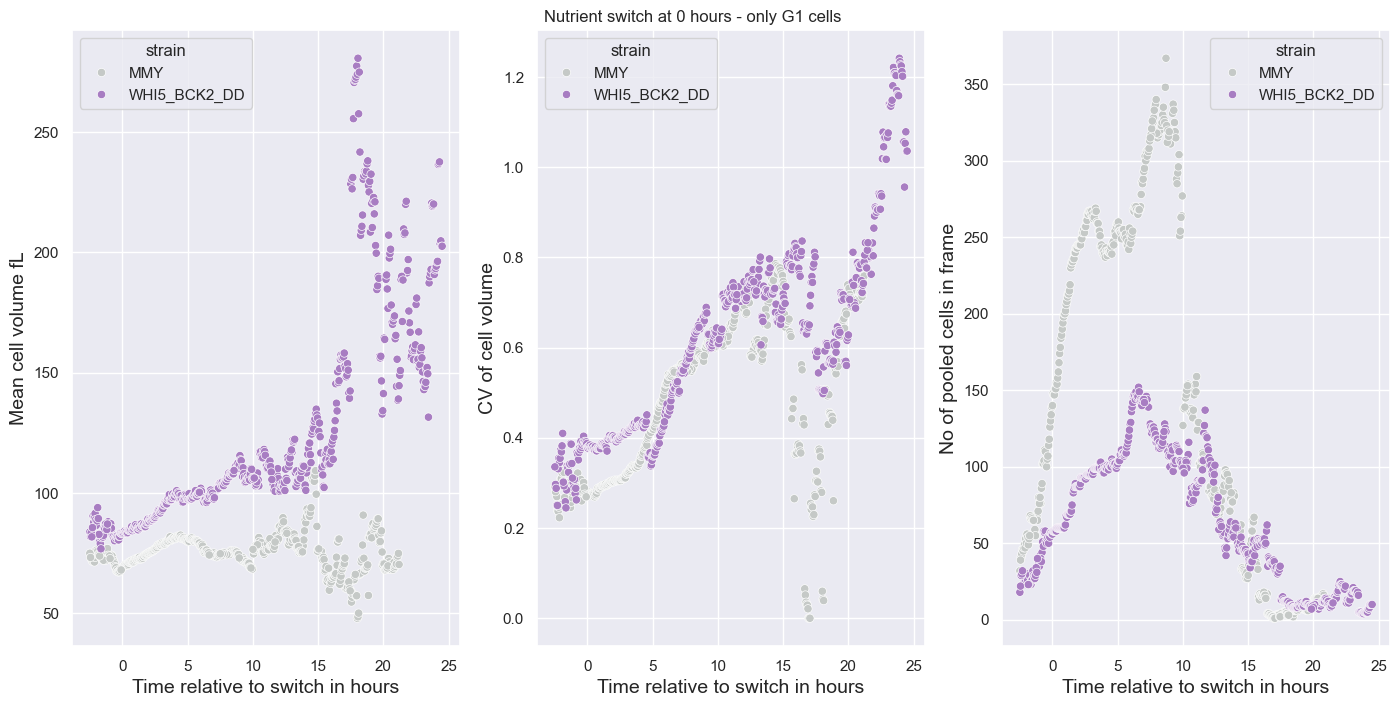

In [43]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - only G1 cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_onlyG1cells')

In [44]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1) & (select_strains_df["cell_cycle_stage"] != "G1")]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for strain in nobud_df['strain'].unique():
        strain_df  = nobud_df[nobud_df['strain'] == strain]
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
            frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
            frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
            frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
            # only append first row from frame_df to have only one row per frame in resulting df
            j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [45]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

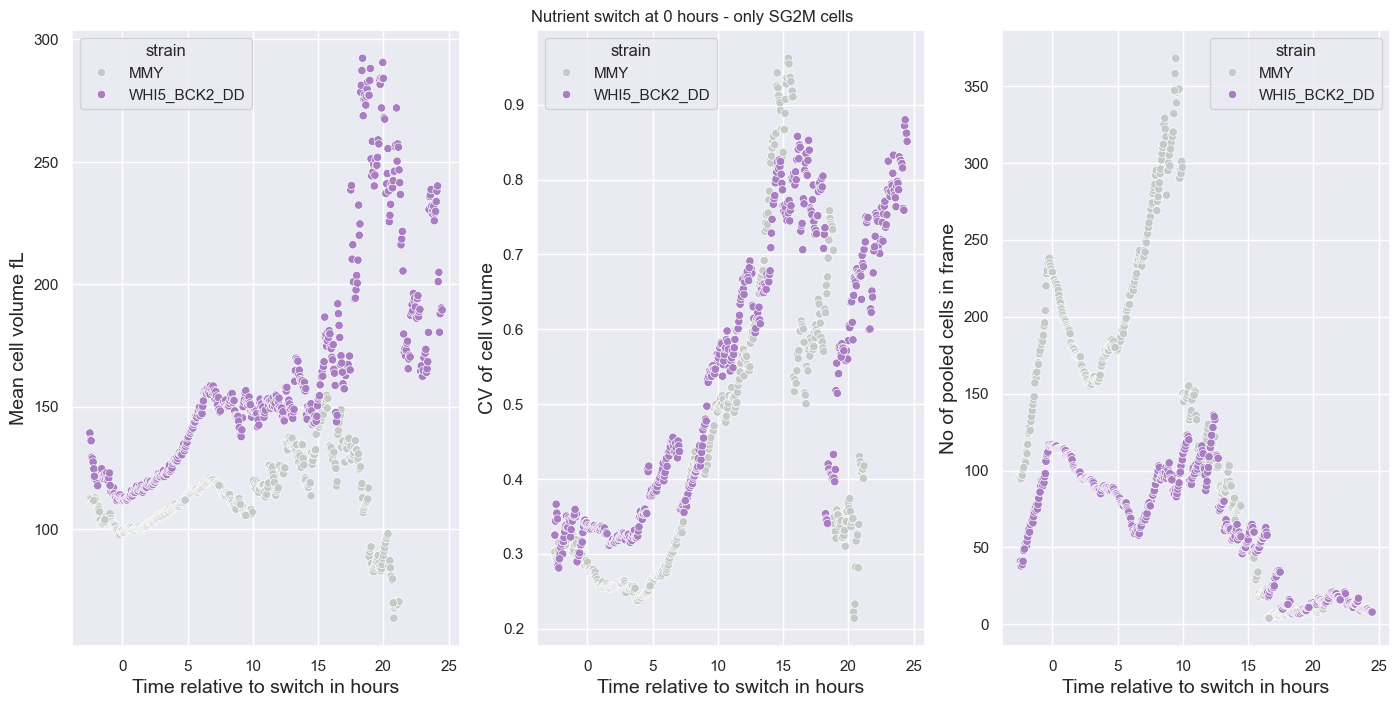

In [46]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - only SG2M cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_onlySG2Mcells')

# ***not used -Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions OF A REP for every frame - REP 2 is an outlier*** 

In [47]:
#display(overall_df_with_rel_and_switch_info.columns.tolist())
select_strains_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                        (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'cell_vol_fl_rel', 'combined_mother_bud_volume', 'f_pos_cell_id']].head(20))

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,cell_vol_fl_rel,combined_mother_bud_volume,f_pos_cell_id
0,0,1,0,S,135.471216,72.948291,208.419507,MMY_Position_1_Cell_1_Gen_2_Rep_1
1,1,1,0,S,131.569655,73.392645,204.962300,MMY_Position_1_Cell_1_Gen_2_Rep_1
2,2,1,0,G1,135.354415,76.026385,135.354415,MMY_Position_1_Cell_1_Gen_3_Rep_1
3,3,1,0,G1,136.988988,77.240173,136.988988,MMY_Position_1_Cell_1_Gen_3_Rep_1
4,4,1,0,G1,131.651731,76.639812,131.651731,MMY_Position_1_Cell_1_Gen_3_Rep_1
5,5,1,0,G1,131.117833,78.965256,131.117833,MMY_Position_1_Cell_1_Gen_3_Rep_1
6,6,1,0,G1,131.318354,82.143631,131.318354,MMY_Position_1_Cell_1_Gen_3_Rep_1
7,7,1,0,S,133.295539,0.881806,134.177345,MMY_Position_1_Cell_1_Gen_3_Rep_1
8,8,1,0,S,130.114343,2.567045,132.681388,MMY_Position_1_Cell_1_Gen_3_Rep_1
9,9,1,0,S,130.534535,3.559139,134.093674,MMY_Position_1_Cell_1_Gen_3_Rep_1


In [48]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []

import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [49]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,...,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,...,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,99.707260,38.147552,0.382596,57
315,110813,30,5400.0,2,0,0,521,459,0,G1,...,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,126.476970,50.986826,0.403131,42
685,155831,30,5400.0,1,0,0,409,261,0,S,...,2,MMY_Position_1_Cell_1_Gen_1_Rep_2,-1.359018,-0.014323,0,nutrient_switch,127.453975,135.604515,1.063949,40
1080,273265,30,5400.0,1,0,0,314,236,0,S,...,2,WHI5_BCK2_DD_Position_30_Cell_1_Gen_3_Rep_2,5.172233,0.036885,0,nutrient_switch,102.495765,35.170584,0.343142,30
1621,300565,30,5400.0,1,0,0,207,225,0,S,...,3,MMY_Position_1_Cell_1_Gen_3_Rep_3,-0.349973,-0.003489,0,nutrient_switch,87.055505,27.530413,0.316240,68
1981,436567,30,5400.0,1,0,0,310,235,0,G1,...,3,WHI5_BCK2_DD_Position_31_Cell_1_Gen_3_Rep_3,NaN,NaN,0,nutrient_switch,105.095884,35.207499,0.335004,49
2381,30,30,5400.0,1,0,0,379,173,0,G1,...,4,MMY_Position_1_Cell_1_Gen_3_Rep_4,0.500872,0.010886,0,nutrient_switch,96.620094,37.343183,0.386495,50
2852,199705,30,30.0,1,0,0,448,172,0,S,...,5,MMY_Position_1_Cell_1_Gen_1_Rep_5,4.157804,0.034138,0,nutrient_switch,99.695861,29.600770,0.296911,54


99.70726047490743

In [50]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

Text(0, 0.5, 'No of pooled cells in frame')

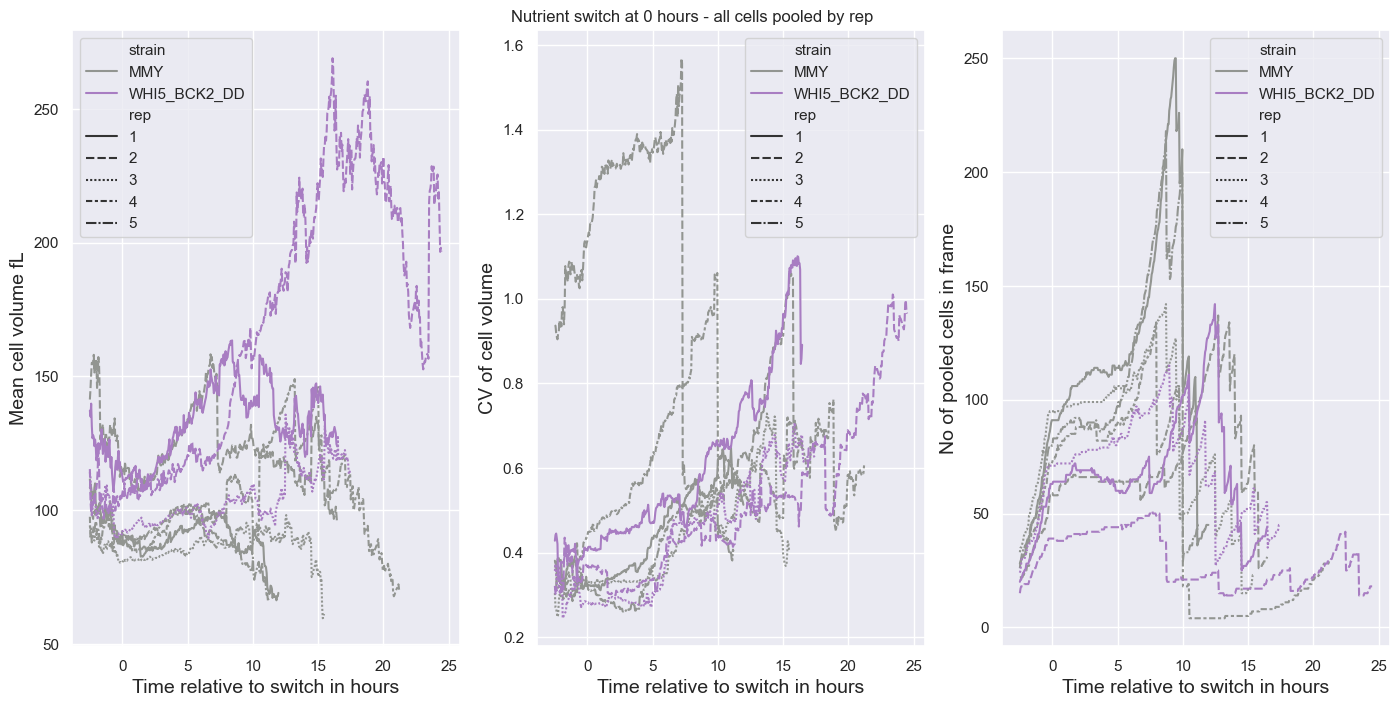

In [51]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                style = 'rep',
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                 style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                 style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

# ***not used - Revision1: plotting frame-specific CVs after the nutrient switch by of each position of each rep - why is rep 2 an outlier*** 

In [52]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
# nobud_df = nobud_df.drop(nobud_df[(nobud_df['rep'] == 2)].index)
import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for pos in strain_df['position'].unique():
                pos_df  = strain_df[strain_df['position'] == pos]
                for frame in pos_df['frame_i'].unique():
                    frame_df = pos_df[pos_df['frame_i'] == frame]
                    frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                    frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                    frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                    frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                    # only append first row from frame_df to have only one row per frame in resulting df
                    j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [53]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['position'] == "Position_1")
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,...,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,...,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,112.684863,36.158300,0.320880,3
284,3329,30,5400.0,1,0,0,508,135,0,S,...,1,MMY_Position_2_Cell_1_Gen_1_Rep_1,-0.016993,-0.000306,0,nutrient_switch,84.182376,21.814078,0.259129,8
539,9485,30,5400.0,1,0,0,517,259,0,S,...,1,MMY_Position_3_Cell_1_Gen_1_Rep_1,2.810272,0.020377,0,nutrient_switch,99.306733,33.689639,0.339248,7
785,15048,30,5400.0,1,0,0,338,324,0,S,...,1,MMY_Position_4_Cell_1_Gen_1_Rep_1,6.004016,0.050266,0,nutrient_switch,148.588453,49.742600,0.334768,4
1037,20113,30,5400.0,5,0,0,659,138,0,S,...,1,MMY_Position_5_Cell_5_Gen_1_Rep_1,0.779957,0.010899,0,nutrient_switch,110.525427,46.139401,0.417455,8
1296,27475,30,5400.0,1,0,0,766,132,0,S,...,1,MMY_Position_6_Cell_1_Gen_1_Rep_1,5.881332,0.052986,0,nutrient_switch,87.515116,22.616034,0.258424,11
1541,35156,30,5400.0,1,0,0,488,341,0,S,...,1,MMY_Position_7_Cell_1_Gen_1_Rep_1,6.714954,0.056976,0,nutrient_switch,95.612792,25.264837,0.264241,7
1817,42024,30,5400.0,1,0,0,431,273,0,G1,...,1,MMY_Position_8_Cell_1_Gen_3_Rep_1,2.226990,0.035122,0,nutrient_switch,84.764300,32.672030,0.385446,6
2053,47017,30,5400.0,1,0,0,545,429,0,S,...,1,MMY_Position_9_Cell_1_Gen_1_Rep_1,0.786359,0.013296,0,nutrient_switch,119.184757,47.217193,0.396168,3
2352,110813,30,5400.0,2,0,0,521,459,0,G1,...,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,179.092517,116.230036,0.648994,3


112.68486332712853

In [54]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

C:\Users\Hp\miniforge3\envs\acdc\lib\site-packages\seaborn\relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


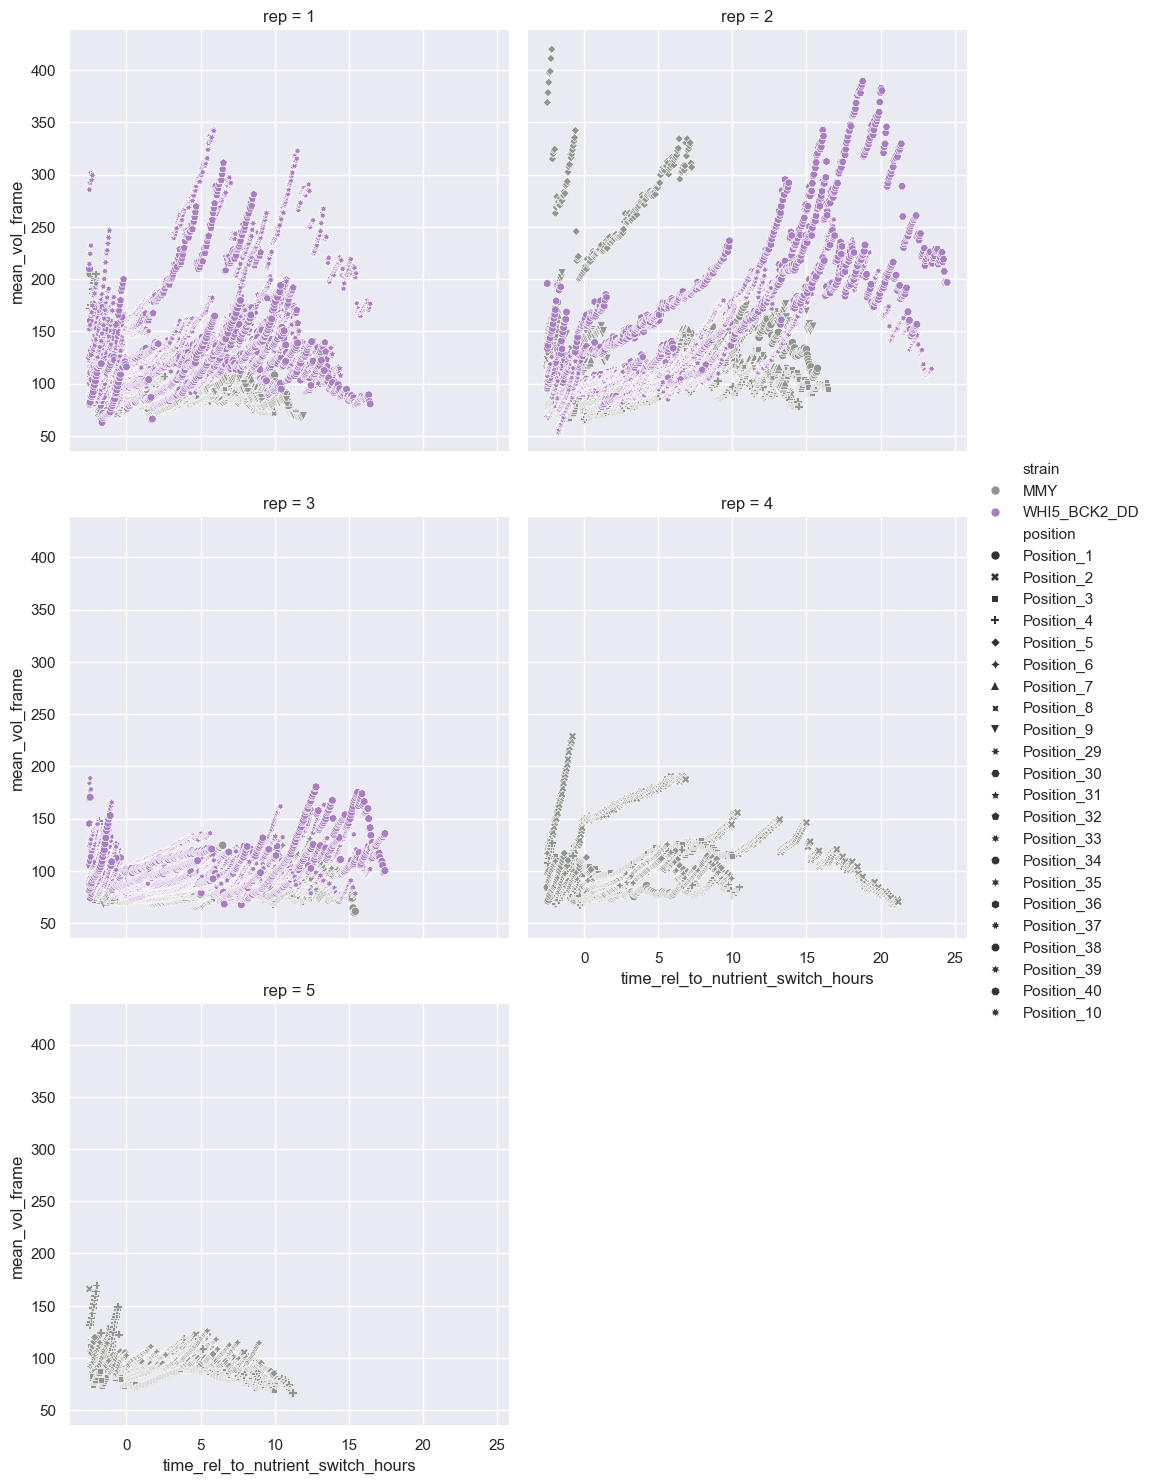

In [55]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
# S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x='time_rel_to_nutrient_switch_hours', 
#                 ax = ax1,
#                 y="mean_vol_frame", 
#                 hue = "strain", 
#                 style = 'pos',
#                 palette = palette
#                    )
S = sns.relplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="mean_vol_frame",
                style = 'position',
                col = 'rep',
                col_wrap = 2,
                hue = "strain", 
                palette = palette
                   )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x= 'time_rel_to_nutrient_switch_hours', 
#                 ax = ax3,
#                 y="n_cells_in_frame_pooled", 
#                 # style = 'rep',
#                 hue = "strain", 
#                 palette = palette
#                    )
# S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
# ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
# ax2.set_ylabel("CV of cell volume", fontsize = 14)
# ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

C:\Users\Hp\miniforge3\envs\acdc\lib\site-packages\seaborn\relational.py:733: UserWarning: relplot is a figure-level function and does not accept the `ax` parameter. You may wish to try scatterplot
  warnings.warn(msg, UserWarning)


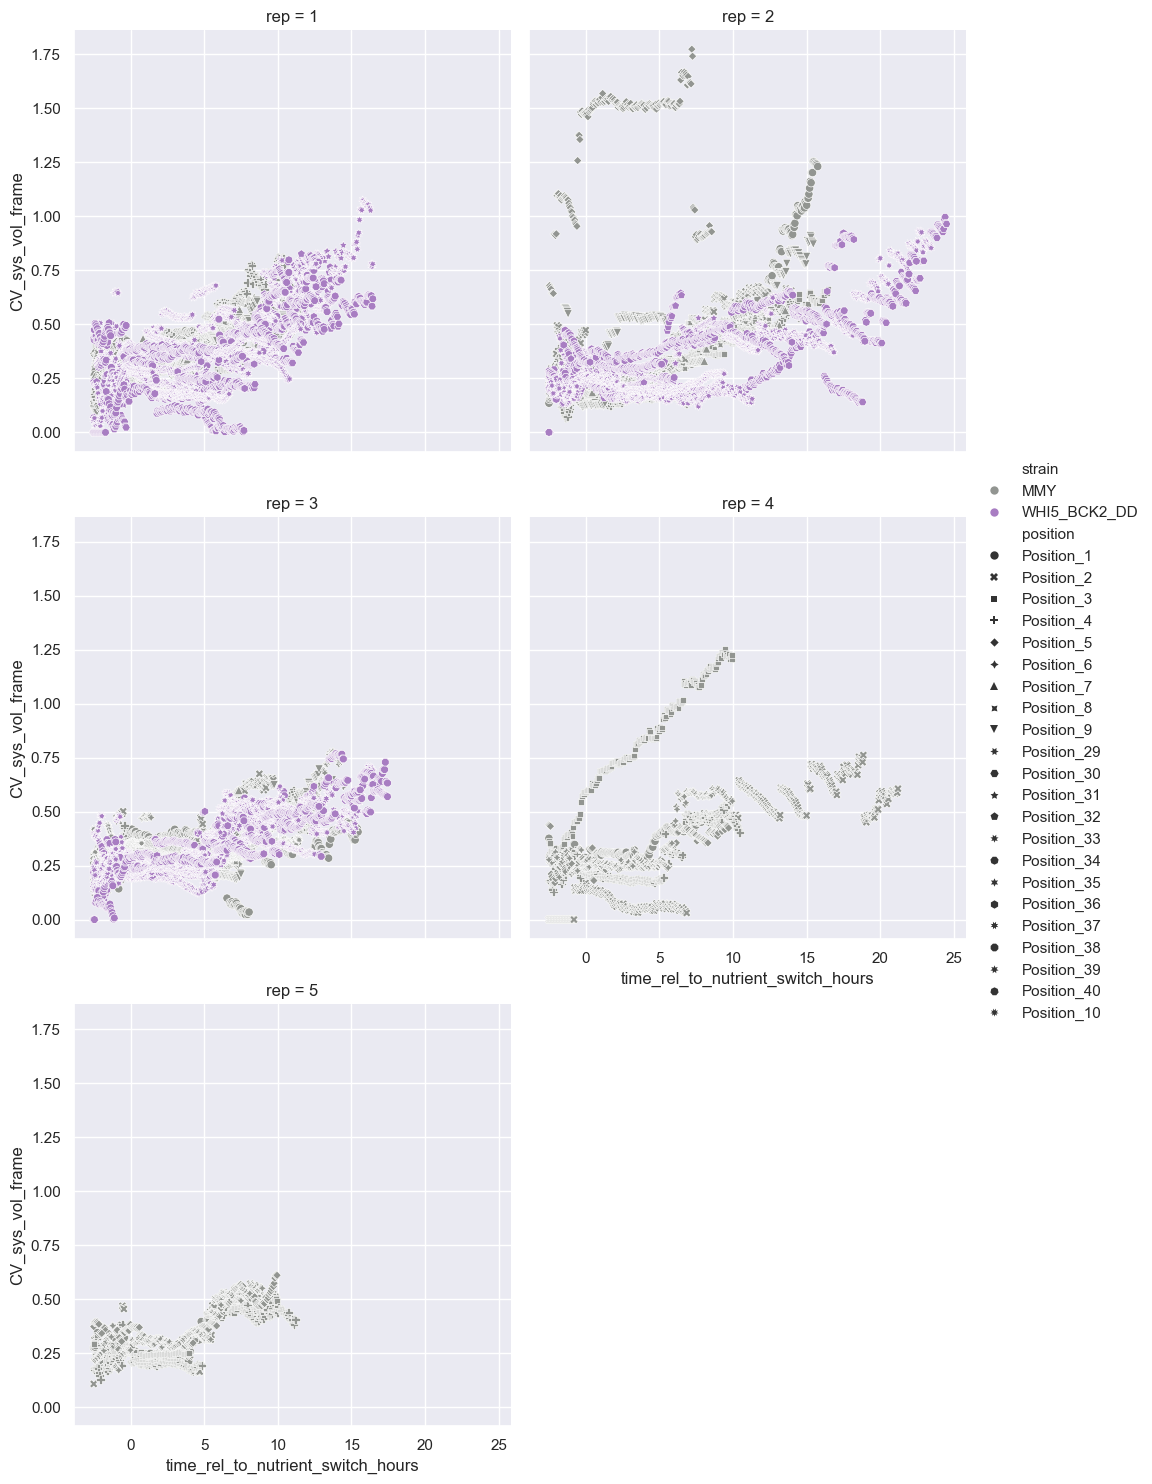

In [56]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
# S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x='time_rel_to_nutrient_switch_hours', 
#                 ax = ax1,
#                 y="mean_vol_frame", 
#                 hue = "strain", 
#                 style = 'pos',
#                 palette = palette
#                    )
S = sns.relplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                style = 'position',
                col = 'rep',
                col_wrap = 2,
                hue = "strain", 
                palette = palette
                   )
# S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
#                 x= 'time_rel_to_nutrient_switch_hours', 
#                 ax = ax3,
#                 y="n_cells_in_frame_pooled", 
#                 # style = 'rep',
#                 hue = "strain", 
#                 palette = palette
#                    )
# S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
# ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
# ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
# ax2.set_ylabel("CV of cell volume", fontsize = 14)
# ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
#plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

In [98]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)
pd.set_option('display.max_colwidth', None)
display(new_nobud_df_with_frame_specific_CVs[(new_nobud_df_with_frame_specific_CVs['rep'] == 2) &
                                            (new_nobud_df_with_frame_specific_CVs['position'] == "Position_5")])

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled


# ***not used - Revision1: we found two strong outlier positions in terms of CV of cell volume from previous cell: rep4 pos3 and rep2 pos5. The outlier behaviour comes from very large (8-10 micron) cells in these positions, so the large CV is real. Also, cell number is low.*** 

# ***not used - Revision1: plotting frame-specific CVs after the nutrient switch by pooling cells from all positions OF A REP for every frame - without the two outlier positions*** 

In [58]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_3") & 
                         (nobud_df['rep'] == 4)
                         ].index)
nobud_df = nobud_df.drop(nobud_df[
                         (nobud_df['position'] == "Position_5") & 
                         (nobud_df['rep'] == 2)
                         ].index)
import warnings
with warnings.catch_warnings(record=True):
    for rep in nobud_df['rep'].unique():
        rep_df  = nobud_df[nobud_df['rep'] == rep]
        for strain in rep_df['strain'].unique():
            strain_df  = rep_df[rep_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["combined_mother_bud_volume"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["combined_mother_bud_volume"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [59]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 30])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['rep'] == 1)
                            & (select_strains_df['frame_i'] == 30)]
display(test_df.combined_mother_bud_volume.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0,frame_i,time_seconds,Cell_ID,is_cell_dead,is_cell_excluded,x_centroid,y_centroid,was_manually_edited,cell_cycle_stage,generation_num,relative_ID,relationship,emerg_frame_i,division_frame_i,is_history_known,corrected_assignment,cell_area_pxl,cell_area_um2,cell_vol_vox,cell_vol_fl,cell_vol_vox_downstream,cell_vol_fl_downstream,2d_label_count,min_t,max_t,lifespan,age,frames_till_gone,elongation,Dia_Ph3_corrected_mean,Dia_Ph3_raw_sum,Dia_Ph3_corrected_amount,Dia_Ph3_corrected_concentration,max_frame_pos,file,selection_subset,position,directory,time_seconds_rel,Cell_ID_rel,is_cell_dead_rel,is_cell_excluded_rel,x_centroid_rel,y_centroid_rel,was_manually_edited_rel,cell_cycle_stage_rel,generation_num_rel,relative_ID_rel,relationship_rel,emerg_frame_i_rel,division_frame_i_rel,is_history_known_rel,corrected_assignment_rel,cell_area_pxl_rel,cell_area_um2_rel,cell_vol_vox_rel,cell_vol_fl_rel,cell_vol_vox_downstream_rel,cell_vol_fl_downstream_rel,2d_label_count_rel,min_t_rel,max_t_rel,lifespan_rel,age_rel,frames_till_gone_rel,elongation_rel,Dia_Ph3_corrected_mean_rel,Dia_Ph3_raw_sum_rel,Dia_Ph3_corrected_amount_rel,Dia_Ph3_corrected_concentration_rel,Dia_Ph3_combined_amount_mother_bud,Dia_Ph3_combined_raw_sum_mother_bud,combined_mother_bud_volume,phase_area_growth,phase_volume_growth,phase_area_at_beginning,phase_volume_at_beginning,phase_volume_at_end,phase_daughter_area_growth,phase_daughter_volume_growth,phase_length,phase_begin,phase_end,phase_combined_volume_at_end,complete_phase,complete_cycle,time_in_phase,time_in_cell_cycle,strain,growthmedium,post_switch_gen,cycle_saw_switch,phase_saw_switch,cell_saw_switch,cell_saw_switch_as_bud,cell_saw_switch_in_G1,cell_saw_switch_in_S,phase_volume_added,S_switch_cells_daughter_wave,daughterhood_binary,frames_since_cycle_start,birth_or_div_frame,birth_or_div_vol,bud_emerg_frame,bud_emerg_sys_vol,div_frame,div_sys_vol,G1_switch_cells_daughter_wave,rep,f_pos_cell_id,vol_added_since_prev_frame_fl,delta_vol_norm_cellvol,does_cell_die_in_this_phase,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
30,30,30,5400.0,1,0,0,372,251,0,S,4.0,8.0,mother,-1.0,22.0,0.0,0.0,4318.0,32.383100,198554.812500,128.953785,198554.81,128.953785,1.0,0.0,294.0,295.0,31.0,264.0,1.154321,762.319361,12376767.0,3291695.0,25526.160402,269,20220908,0,Position_1,Y:/Analysed Live cell microscopy data/20220908\Position_1\Images,5400.0,8.0,0.0,0.0,344.0,214.0,0.0,S,0.0,1.0,bud,24.0,-1.0,1.0,0.0,516.0,3.869773,7687.651855,4.992837,7687.6520,4.992837,1.0,24.0,294.0,271.0,7.0,264.0,1.286996,1315.930233,1764684.0,679020.0,135998.833293,3970715.0,14141451.0,133.946622,0.202488,0.997117,32.435597,129.503778,130.500895,19.806338,64.366999,24,24.0,48.0,195.209888,1,1,7.0,9,MMY,SCD,NaN,False,False,True,False,True,False,0.997117,NaN,0,8.0,22.0,129.194786,24.0,129.845772,48.0,195.209888,NaN,1,MMY_Position_1_Cell_1_Gen_4_Rep_1,0.724692,0.005410,0,nutrient_switch,99.707260,38.147552,0.382596,57
315,110813,30,5400.0,2,0,0,521,459,0,G1,2.0,29.0,mother,-1.0,28.0,0.0,0.0,4063.0,30.470712,187137.187500,121.538473,187137.19,121.538473,1.0,0.0,429.0,430.0,31.0,399.0,1.081366,1049.240955,12108719.0,4263066.0,35075.856300,304,20220908,0,Position_29,Y:/Analysed Live cell microscopy data/20220908\Position_29\Images,5400.0,29.0,0.0,0.0,589.0,462.0,0.0,G1,1.0,2.0,mother,8.0,28.0,1.0,0.0,3064.0,22.978652,114754.531250,74.528695,114754.5300,74.528695,1.0,8.0,309.0,302.0,23.0,279.0,1.227728,845.247715,8506423.0,2589839.0,34749.554983,4263066.0,12108719.0,121.538473,0.944945,2.299572,29.233285,117.182958,119.482530,1.979884,4.389814,3,28.0,31.0,119.482530,1,1,3.0,3,WHI5_BCK2_DD,SCD,switch_gen,True,False,True,False,False,True,2.299572,NaN,0,2.0,28.0,117.182958,32.0,117.854963,197.0,348.706199,NaN,1,WHI5_BCK2_DD_Position_29_Cell_2_Gen_2_Rep_1,1.573758,0.012949,0,nutrient_switch,126.476970,50.986826,0.403131,42
685,155831,30,5400.0,1,0,0,409,261,0,S,1.0,10.0,mother,-1.0,15.0,0.0,0.0,3158.0,23.683610,123953.367188

99.70726047490743

In [60]:
new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch'] = new_nobud_df_with_frame_specific_CVs['frame_i'] - 50
new_nobud_df_with_frame_specific_CVs['time_rel_to_nutrient_switch_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_rel_to_nutrient_switch']*3)/60

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\yagya.chadha\\Desktop\\Yagya\\Presentations\\Plots from Python\\Final figures\\revision figs\\post_switch_repwiseCVs_microscopy_allcells_outlierPosRemoved.png'

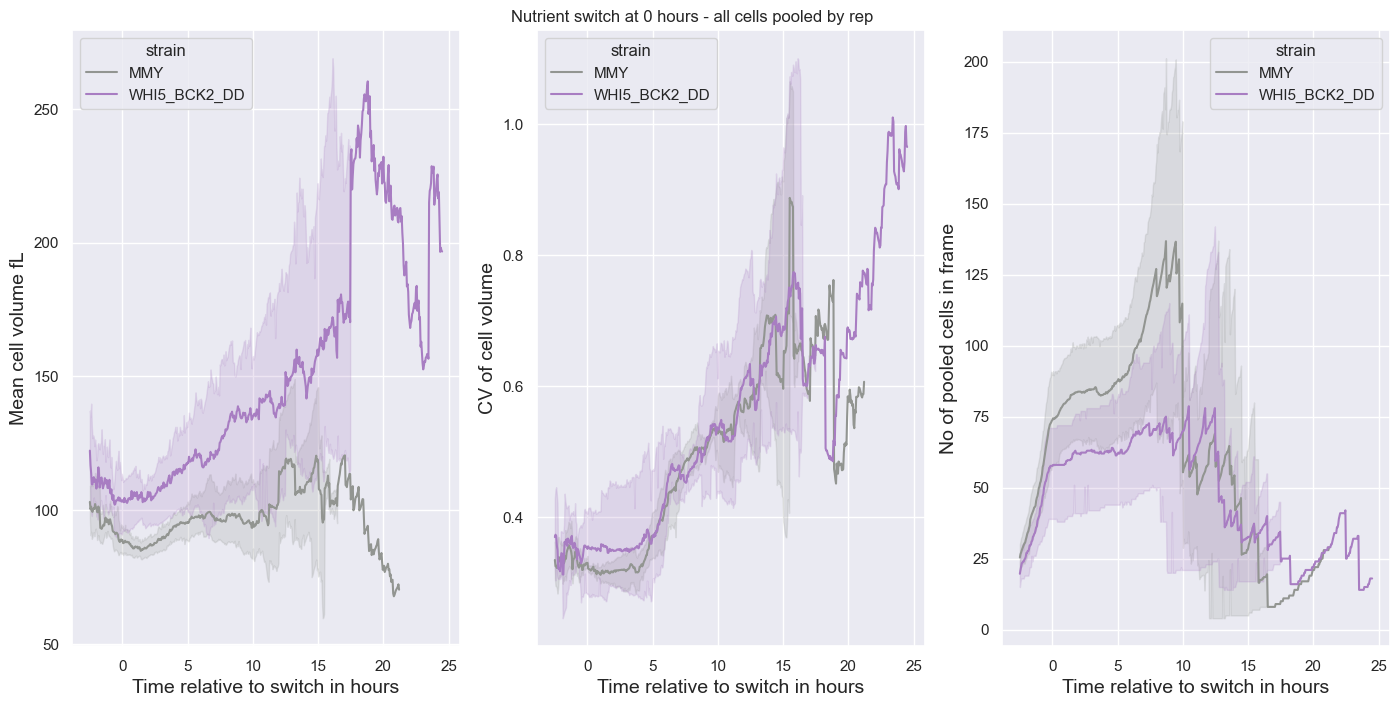

In [61]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x='time_rel_to_nutrient_switch_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                #style = 'rep',
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax2,
                y="CV_sys_vol_frame",
                # style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S = sns.lineplot(data = new_nobud_df_with_frame_specific_CVs,
                x= 'time_rel_to_nutrient_switch_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                # style = 'rep',
                hue = "strain", 
                palette = palette
                   )
S.set_title("Nutrient switch at 0 hours - all cells pooled by rep", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax2.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax3.set_xlabel("Time relative to switch in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_repwiseCVs_microscopy_allcells_outlierPosRemoved')

# ***not used - Revision1: calculating and plotting steady state frame-specific cell vol CVs for both media*** 

In [62]:
#calculating and plotting steady state frame-specific cell vol CVs for both media

In [63]:
display(SS_SCDnSCGE.columns.tolist())
select_strains_df = SS_SCDnSCGE[(SS_SCDnSCGE['strain'] == "MMY")|
                                (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD")]
display(select_strains_df[['frame_i', 'Cell_ID', 'is_cell_dead', 'cell_cycle_stage', 'cell_vol_fl', 'rel_vol_atframe', 'sys_vol_atframe','sys_vol_at_frame_inc_G1_cells', 'f_pos_cell_id', 'relationship', 'generation_num']].head(30))

['Unnamed: 0.2',
 'Unnamed: 0.1',
 'Unnamed: 0',
 'generation_num',
 'position',
 'Cell_ID',
 'growthmedium',
 'frame_i',
 'cell_cycle_stage',
 'relative_ID',
 'relationship',
 'cell_vol_fl',
 'emerg_frame_i',
 'division_frame_i',
 'len_G1',
 'rep',
 'strain',
 'Birth frame',
 'Birth vol fl',
 'last_G1_frame',
 'size_G1_end',
 'vol_added_G1',
 'Div frame',
 'Div vol fl',
 'len_S',
 'mother_size_emerg',
 'mother_size_div',
 'vol_added_S_mother',
 'bud_size_emerg',
 'bud_size_div',
 'vol_added_S_bud',
 'sys_size_emerg',
 'sys_size_div',
 'vol_added_S_tot',
 'total vol added',
 'time_seconds',
 'is_cell_dead',
 'complete_phase',
 'lenG1_mins',
 'G1_growthrate_flpermin',
 'delta_vol_fl',
 'delta_time_mins',
 'abs_growth_rate',
 'Birth_or_div_vol_fl',
 'rel_vol_atframe',
 'sys_vol_atframe',
 'delta_vol_sincePhaseStart_mother',
 'delta_vol_sincePhaseStart_sys',
 'norm_delta_vol_sincePhaseStart_mother',
 'norm_delta_vol_sincePhaseStart_sys',
 'bud_vol_atframe/mother_vol_atframe',
 'delta_vol_

,frame_i,Cell_ID,is_cell_dead,cell_cycle_stage,cell_vol_fl,rel_vol_atframe,sys_vol_atframe,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,relationship,generation_num
0,0,1.0,0,S,58.256695,92.927348,151.184043,151.184043,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
1,1,1.0,0,S,60.404339,93.706004,154.110342,154.110342,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
2,2,1.0,0,S,61.139191,94.112864,155.252054,155.252054,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
3,3,1.0,0,S,62.500215,95.679685,158.179900,158.179900,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
4,4,1.0,0,S,63.211776,97.265445,160.477221,160.477221,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
5,5,1.0,0,S,63.341337,99.942398,163.283735,163.283735,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
6,6,1.0,0,S,64.975784,102.084921,167.060705,167.060705,SCD_MMY_Position_1_Cell_1.0_Gen_0_Date_20012021,bud,0.0
7,7,1.0,0,G1,67.499547,NaN,NaN,67.499547,SCD_MMY_Position_1_Cell_1.0_Gen_1_Date_20012021,mother,1.0
8,8,1.0,0,G1,67.411987,NaN,NaN,67.411987,SCD_MMY_Position_1_Cell_1.0_Gen_1_Date_20012021,mother,1.0
9,9,1.0,0,G1,68.835553,NaN,NaN,68.835553,SCD_MMY_Position_1_Cell_1.0_Gen_1_Date_20012021,mother,1.0


In [64]:
#remove buds from dataset because their volumes are already recorded with their mothers
#for each frame in each strain separately, calculate mean, std and CV for all cells present in the frame (pos and reps pooled)
nobud_df= select_strains_df[(select_strains_df["relationship"] != "bud") & (select_strains_df["is_cell_dead"] != 1)]
j = []

import warnings
with warnings.catch_warnings(record=True):
    for medium in nobud_df['growthmedium'].unique():
        medium_df  = nobud_df[nobud_df['growthmedium'] == medium]
        for strain in medium_df['strain'].unique():
            strain_df  = medium_df[medium_df['strain'] == strain]
            for frame in strain_df['frame_i'].unique():
                frame_df = strain_df[strain_df['frame_i'] == frame]
                frame_df["mean_vol_frame"] = (frame_df["sys_vol_at_frame_inc_G1_cells"]).mean()
                frame_df["stdev_vol_frame"] = np.std(frame_df["sys_vol_at_frame_inc_G1_cells"])
                frame_df["CV_sys_vol_frame"] = (frame_df["stdev_vol_frame"])/(frame_df["mean_vol_frame"])
                frame_df["n_cells_in_frame_pooled"] = len(frame_df.f_pos_cell_id.unique())
                # only append first row from frame_df to have only one row per frame in resulting df
                j.append(frame_df.iloc[:1])

new_nobud_df_with_frame_specific_CVs = pd.concat(j).reset_index(drop = True)

In [65]:
# testing if loop in previous cell does what we want
display(new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['frame_i'] == 1])
test_df = select_strains_df[(select_strains_df['strain'] == "MMY") 
                            & (select_strains_df['relationship'] != "bud")
                            & (select_strains_df['is_cell_dead'] != 1)
                            & (select_strains_df['growthmedium'] == "SCD")
                            & (select_strains_df['frame_i'] == 1)]
display(test_df.sys_vol_at_frame_inc_G1_cells.mean())
# display(np.std(test_df.combined_mother_bud_volume))
#display(new_nobud_df_with_frame_specific_CVs.columns.tolist())

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,generation_num,position,Cell_ID,growthmedium,frame_i,cell_cycle_stage,relative_ID,relationship,cell_vol_fl,emerg_frame_i,division_frame_i,len_G1,rep,strain,Birth frame,Birth vol fl,last_G1_frame,size_G1_end,vol_added_G1,Div frame,Div vol fl,len_S,mother_size_emerg,mother_size_div,vol_added_S_mother,bud_size_emerg,bud_size_div,vol_added_S_bud,sys_size_emerg,sys_size_div,vol_added_S_tot,total vol added,time_seconds,is_cell_dead,complete_phase,lenG1_mins,G1_growthrate_flpermin,delta_vol_fl,delta_time_mins,abs_growth_rate,Birth_or_div_vol_fl,rel_vol_atframe,sys_vol_atframe,delta_vol_sincePhaseStart_mother,delta_vol_sincePhaseStart_sys,norm_delta_vol_sincePhaseStart_mother,norm_delta_vol_sincePhaseStart_sys,bud_vol_atframe/mother_vol_atframe,delta_vol_sinceG1Start,norm_delta_vol_sinceG1Start,Daughterhood_binary,time_in_stage_mins,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,complete_cycle,frames_since_cycle_start,vol_added_since_last_frame,delta_vol_norm_cellvol,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled
87,271,271,271.0,2.0,Position_1,4.0,SCD,1,S,1.0,mother,93.706004,-1.0,-1.0,NaN,20012021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,60.404339,154.110342,NaN,NaN,NaN,NaN,0.644615,NaN,NaN,0,3.0,154.110342,SCD_MMY_Position_1_Cell_4.0_Gen_2_Date_20012021,0.0,1.0,2.926300,0.018988,steady state,82.616140,33.454366,0.404937,64
181,25699,25699,25699.0,2.0,Position_20,2.0,SCD,1,S,5.0,mother,131.495677,-1.0,-1.0,NaN,20012021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,57.152393,188.648071,NaN,NaN,NaN,NaN,0.434633,NaN,NaN,0,3.0,188.648071,SCD_WHI5_BCK2_DD_Position_20_Cell_2.0_Gen_2_Date_20012021,0.0,1.0,3.013392,0.015974,steady state,96.968070,37.899369,0.390844,70
213,121010,121010,121010.0,2.0,Position_1,1.0,SCGE,1,G1,-1.0,mother,56.028432,-1.0,-1.0,NaN,23092021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,56.028432,SCGE_MMY_Position_1_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,0.152537,0.002722,steady state,66.320359,32.439308,0.489130,47
513,189839,189839,189839.0,2.0,Position_29,1.0,SCGE,1,S,6.0,mother,117.399729,-1.0,-1.0,NaN,23092021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,11.244754,128.644483,NaN,NaN,NaN,NaN,0.095782,NaN,NaN,0,3.0,128.644483,SCGE_WHI5_BCK2_DD_Position_29_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,-0.523383,-0.004068,steady state,87.733620,47.059441,0.536390,41


82.61613960086679

In [66]:
new_nobud_df_with_frame_specific_CVs['time_in_hours'] = (new_nobud_df_with_frame_specific_CVs['frame_i']*3)/60
new_nobud_df_with_frame_specific_CVs.sort_values(by = 'frame_i', inplace = True)
display(new_nobud_df_with_frame_specific_CVs.head(20))

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,generation_num,position,Cell_ID,growthmedium,frame_i,cell_cycle_stage,relative_ID,relationship,cell_vol_fl,emerg_frame_i,division_frame_i,len_G1,rep,strain,Birth frame,Birth vol fl,last_G1_frame,size_G1_end,vol_added_G1,Div frame,Div vol fl,len_S,mother_size_emerg,mother_size_div,vol_added_S_mother,bud_size_emerg,bud_size_div,vol_added_S_bud,sys_size_emerg,sys_size_div,vol_added_S_tot,total vol added,time_seconds,is_cell_dead,complete_phase,lenG1_mins,G1_growthrate_flpermin,delta_vol_fl,delta_time_mins,abs_growth_rate,Birth_or_div_vol_fl,rel_vol_atframe,sys_vol_atframe,delta_vol_sincePhaseStart_mother,delta_vol_sincePhaseStart_sys,norm_delta_vol_sincePhaseStart_mother,norm_delta_vol_sincePhaseStart_sys,bud_vol_atframe/mother_vol_atframe,delta_vol_sinceG1Start,norm_delta_vol_sinceG1Start,Daughterhood_binary,time_in_stage_mins,sys_vol_at_frame_inc_G1_cells,f_pos_cell_id,complete_cycle,frames_since_cycle_start,vol_added_since_last_frame,delta_vol_norm_cellvol,experiment_type,mean_vol_frame,stdev_vol_frame,CV_sys_vol_frame,n_cells_in_frame_pooled,time_in_hours
180,25698,25698,25698.0,2.0,Position_20,2.0,SCD,0,S,5.0,mother,131.888886,-1.0,-1.0,NaN,20012021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,53.745793,185.634679,NaN,NaN,NaN,NaN,0.407508,NaN,NaN,0,0.0,185.634679,SCD_WHI5_BCK2_DD_Position_20_Cell_2.0_Gen_2_Date_20012021,0.0,0.0,NaN,NaN,steady state,98.457389,37.422897,0.380092,67,0.00
512,189838,189838,189838.0,2.0,Position_29,1.0,SCGE,0,S,6.0,mother,118.315411,-1.0,-1.0,NaN,23092021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,10.852455,129.167866,NaN,NaN,NaN,NaN,0.091725,NaN,NaN,0,0.0,129.167866,SCGE_WHI5_BCK2_DD_Position_29_Cell_1.0_Gen_2_Date_23092021,0.0,0.0,NaN,NaN,steady state,91.507627,50.812218,0.555279,39,0.00
212,121009,121009,121009.0,2.0,Position_1,1.0,SCGE,0,G1,-1.0,mother,55.875895,-1.0,-1.0,NaN,23092021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,55.875895,SCGE_MMY_Position_1_Cell_1.0_Gen_2_Date_23092021,0.0,0.0,NaN,NaN,steady state,73.937696,35.026017,0.473723,42,0.00
86,270,270,270.0,2.0,Position_1,4.0,SCD,0,S,1.0,mother,92.927348,-1.0,-1.0,NaN,20012021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,False,NaN,NaN,74.133357,18,4.118520,NaN,58.256695,151.184043,NaN,NaN,NaN,NaN,0.626906,NaN,NaN,0,0.0,151.184043,SCD_MMY_Position_1_Cell_4.0_Gen_2_Date_20012021,0.0,0.0,NaN,NaN,steady state,83.377499,32.550240,0.390396,61,0.00
513,189839,189839,189839.0,2.0,Position_29,1.0,SCGE,1,S,6.0,mother,117.399729,-1.0,-1.0,NaN,23092021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,33.996570,51,0.666599,NaN,11.244754,128.644483,NaN,NaN,NaN,NaN,0.095782,NaN,NaN,0,3.0,128.644483,SCGE_WHI5_BCK2_DD_Position_29_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,-0.523383,-0.004068,steady state,87.733620,47.059441,0.536390,41,0.05
181,25699,25699,25699.0,2.0,Position_20,2.0,SCD,1,S,5.0,mother,131.495677,-1.0,-1.0,NaN,20012021.0,WHI5_BCK2_DD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,71.213984,12,5.934499,NaN,57.152393,188.648071,NaN,NaN,NaN,NaN,0.434633,NaN,NaN,0,3.0,188.648071,SCD_WHI5_BCK2_DD_Position_20_Cell_2.0_Gen_2_Date_20012021,0.0,1.0,3.013392,0.015974,steady state,96.968070,37.899369,0.390844,70,0.05
213,121010,121010,121010.0,2.0,Position_1,1.0,SCGE,1,G1,-1.0,mother,56.028432,-1.0,-1.0,NaN,23092021.0,MMY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.0,0,False,NaN,NaN,96.991980,210,0.461867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,56.028432,SCGE_MMY_Position_1_Cell_1.0_Gen_2_Date_23092021,0.0,1.0,0.152537,0.002722,steady s

Text(0, 0.5, 'No of pooled cells in frame')

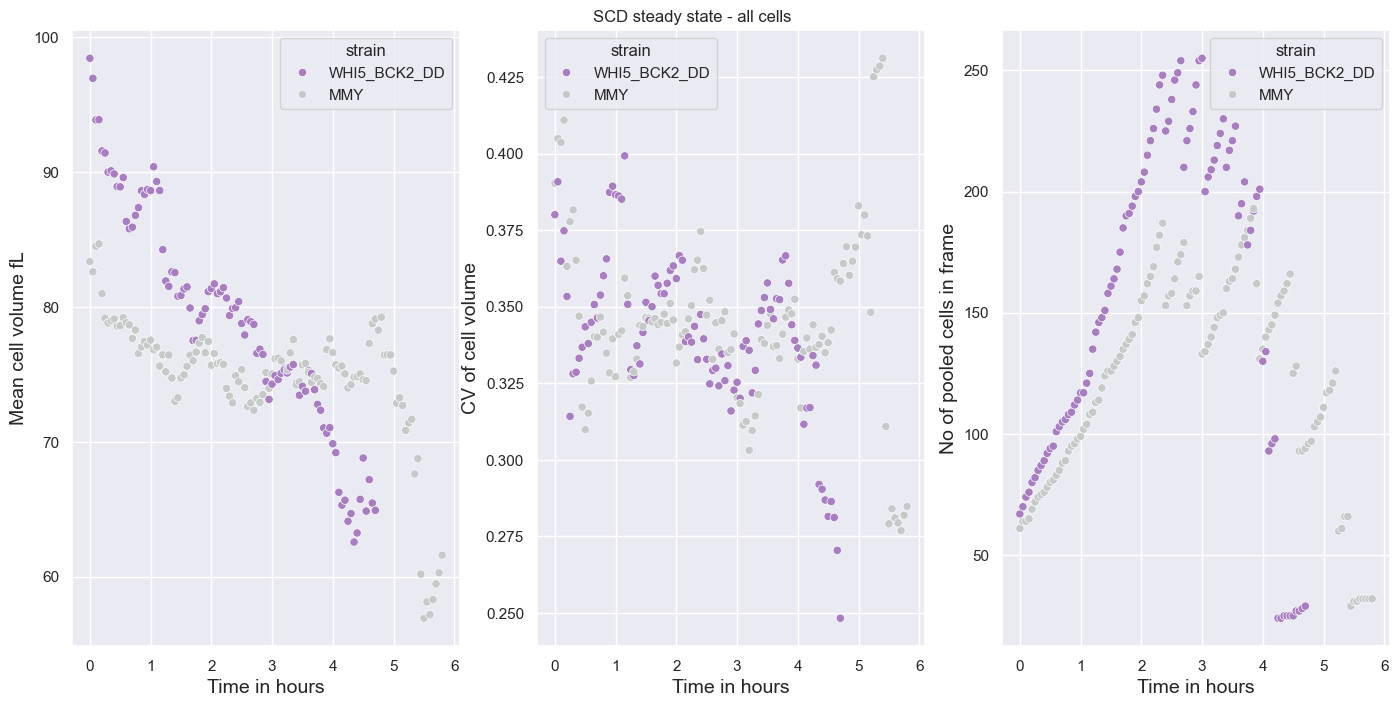

In [67]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x='time_in_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x= 'time_in_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCD"],
                x= 'time_in_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("SCD steady state - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time in hours", fontsize = 14)
ax2.set_xlabel("Time in hours", fontsize = 14)
ax3.set_xlabel("Time in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

Text(0, 0.5, 'No of pooled cells in frame')

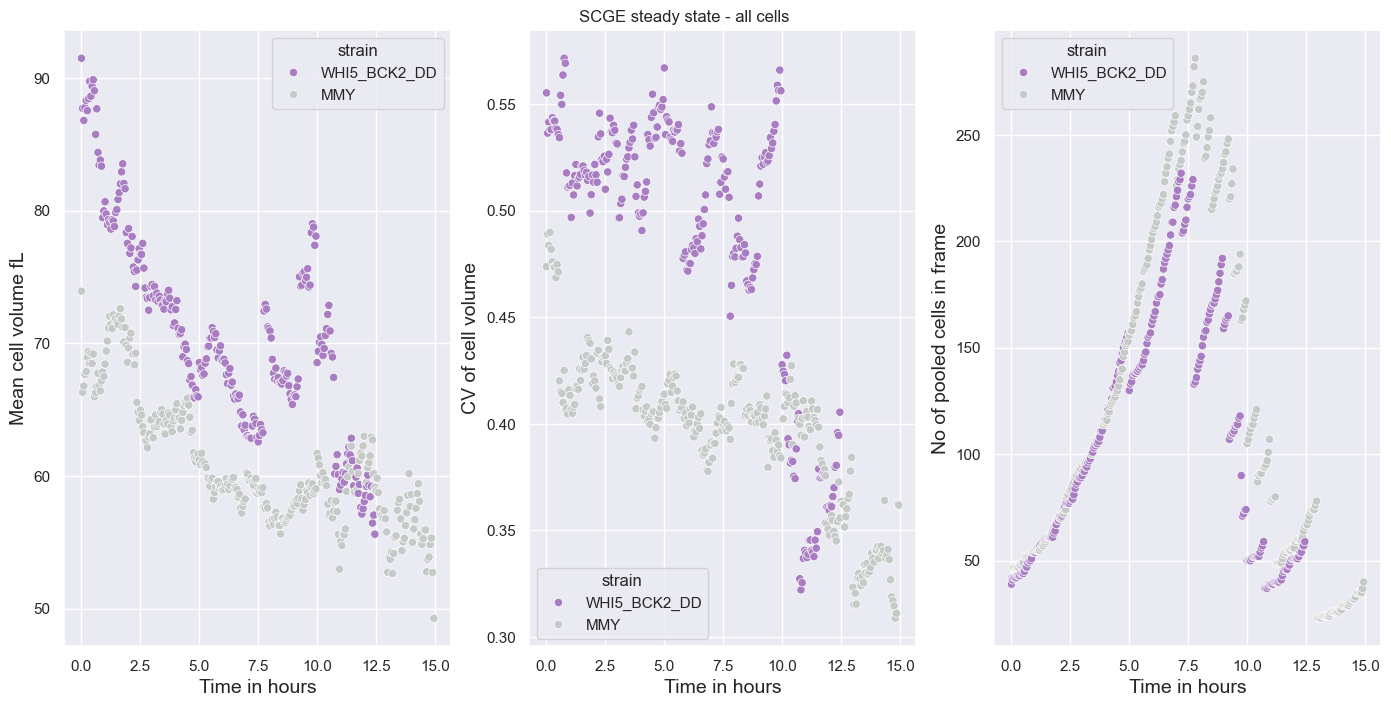

In [68]:
#plot CV of cell volume at every frame against time in hours for MMY and whi5bck2dd 
palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}
S, ((ax1, ax2, ax3)) = plt.subplots(nrows=1, ncols=3, sharex= True, sharey= False, figsize=(17, 8) )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x='time_in_hours', 
                ax = ax1,
                y="mean_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x= 'time_in_hours', 
                ax = ax2,
                y="CV_sys_vol_frame", 
                hue = "strain", 
                palette = palette
                   )
S = sns.scatterplot(data = new_nobud_df_with_frame_specific_CVs[new_nobud_df_with_frame_specific_CVs['growthmedium'] == "SCGE"],
                x= 'time_in_hours', 
                ax = ax3,
                y="n_cells_in_frame_pooled", 
                hue = "strain", 
                palette = palette
                   )
S.set_title("SCGE steady state - all cells", fontsize = 12, x= -0.8)
ax1.set_xlabel("Time in hours", fontsize = 14)
ax2.set_xlabel("Time in hours", fontsize = 14)
ax3.set_xlabel("Time in hours", fontsize = 14)
ax1.set_ylabel("Mean cell volume fL", fontsize = 14)
ax2.set_ylabel("CV of cell volume", fontsize = 14)
ax3.set_ylabel("No of pooled cells in frame", fontsize = 14)
# plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\revision figs\post_switch_CVs_microscopy_allcells')

# ***Revision1: Size control plots for switchers and first daughters of S/G2/M switchers - WT and DD*** 

In [50]:

######################################### filter for steady state cells with complete G1s only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & (SS_SCDnSCGE['cell_cycle_stage'] == "G1")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]

In [51]:
# display(overall_df_with_rel_and_switch_info.S_switch_cells_daughter_wave.dtype)

In [52]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                      ]    
        

In [53]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]
        

In [54]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            & (selectedstrains_NS_plotting_df['cell_cycle_stage'] == "G1")
                                                            ]
        

In [55]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth

In [56]:


###############################################  steadystate  #####################################################################

SCD_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCD"]
SCGE_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCGE"]

#unique plotting df SCD
unique_f_pos_cell_id = []
for fposid in ((SCD_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCD_steadystate_df[SCD_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id.append(fposid_df.iloc[:1])
SCD_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id).reset_index(drop = True) 
SCD_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCD_SS"
SCD_steadystate_daughters_plotting_df.rename(columns={"Birth_or_div_vol_fl": "birth_or_div_vol", "vol_added_G1": "phase_volume_growth"}, inplace = True)

#unique plotting df SCGE
unique_f_pos_cell_id_5 = []
for fposid in ((SCGE_steadystate_df['f_pos_cell_id']).unique()):
    fposid_df = SCGE_steadystate_df[SCGE_steadystate_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['Birth_or_div_vol_fl'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_5.append(fposid_df.iloc[:1])
SCGE_steadystate_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_5).reset_index(drop = True)
SCGE_steadystate_daughters_plotting_df['plotting_col_ref'] = "SCGE_SS"
SCGE_steadystate_daughters_plotting_df.rename(columns={"Birth_or_div_vol_fl": "birth_or_div_vol", "vol_added_G1": "phase_volume_growth"}, inplace = True)

##################################################  nutrient switch  ###################################################################

# unique plotting df nutrient switch firstSG2M_daughters
unique_f_pos_cell_id_3 = []
for fposid in ((firstSG2M_daughters_df['f_pos_cell_id']).unique()):
    fposid_df = firstSG2M_daughters_df[firstSG2M_daughters_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_3.append(fposid_df.iloc[:1])
firstSG2M_daughters_plotting_df = pd.concat(unique_f_pos_cell_id_3).reset_index(drop = True)
firstSG2M_daughters_plotting_df['plotting_col_ref'] = "firstSG2M_daughters"

# unique plotting df nutrient switch G1_switchers
unique_f_pos_cell_id_4 = []
for fposid in ((G1_switchers_switchcycle_df['f_pos_cell_id']).unique()):
    fposid_df = G1_switchers_switchcycle_df[G1_switchers_switchcycle_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_4.append(fposid_df.iloc[:1])
G1_switchers_switchcycle_plotting_df = pd.concat(unique_f_pos_cell_id_4).reset_index(drop = True)
G1_switchers_switchcycle_plotting_df['plotting_col_ref'] = "G1_switchers"

# unique plotting df nutrient switch SG2M_switchers
unique_f_pos_cell_id_6 = []
for fposid in ((SG2M_switchers_switchcycle_df['f_pos_cell_id']).unique()):
    fposid_df = SG2M_switchers_switchcycle_df[SG2M_switchers_switchcycle_df['f_pos_cell_id'] == fposid]
    fposid_df = fposid_df.sort_values(by=['frame_i'])
    if (len(fposid_df['birth_or_div_vol'].unique())) > 1:
        print("HELP", fposid_df)
    unique_f_pos_cell_id_6.append(fposid_df.iloc[:1])
SG2M_switchers_switchcycle_plotting_df = pd.concat(unique_f_pos_cell_id_6).reset_index(drop = True)
SG2M_switchers_switchcycle_plotting_df['plotting_col_ref'] = "SG2M_switchers"


figure_plotting_df = pd.concat([SCD_steadystate_daughters_plotting_df, SCGE_steadystate_daughters_plotting_df, firstSG2M_daughters_plotting_df, G1_switchers_switchcycle_plotting_df, SG2M_switchers_switchcycle_plotting_df]).reset_index(drop = True)


C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


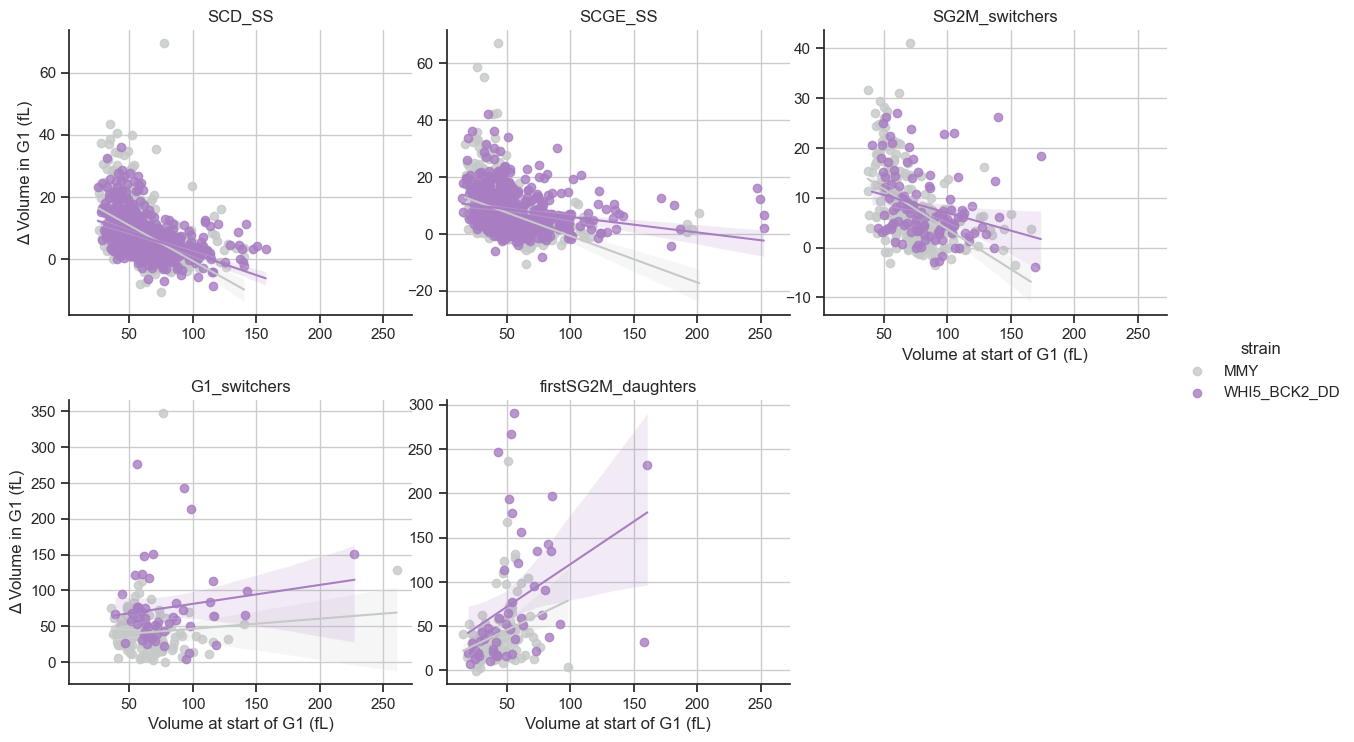

In [57]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df, 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 3,
                  sharey =False,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.regplot, 
      "birth_or_div_vol",
      "phase_volume_growth")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set()
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Volume at start of G1 (fL)", "Δ Volume in G1 (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_sizecontrol_categoryspecific_computer.png")
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_sizecontrol_categoryspecific_computer.svg")





plt.show()

In [58]:
bins = np.linspace(0, figure_plotting_df.birth_or_div_vol.max(), 10)
figure_plotting_df['birth_vol_bin'] = np.digitize(np.array(figure_plotting_df.birth_or_div_vol), bins)
display(bins)
bin_labels = []

for lowerlimit in bins:
    bin_center = lowerlimit + 14.470755217969167
    bin_labels.append(bin_center)

# display(bin_labels)
# display((figure_plotting_df["birth_vol_bin"].unique()))
for bin_num in (figure_plotting_df["birth_vol_bin"].unique()):
    bin_center = bin_labels[bin_num-1]
    figure_plotting_df.loc[(figure_plotting_df["birth_vol_bin"] == bin_num), "bin_center"] = bin_center.round()
# display(figure_plotting_df[["birth_vol_bin", "bin_center"]].head(20))


array([  0.        ,  28.94151044,  57.88302087,  86.82453131,
       115.76604174, 144.70755218, 173.64906262, 202.59057305,
       231.53208349, 260.47359392])

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


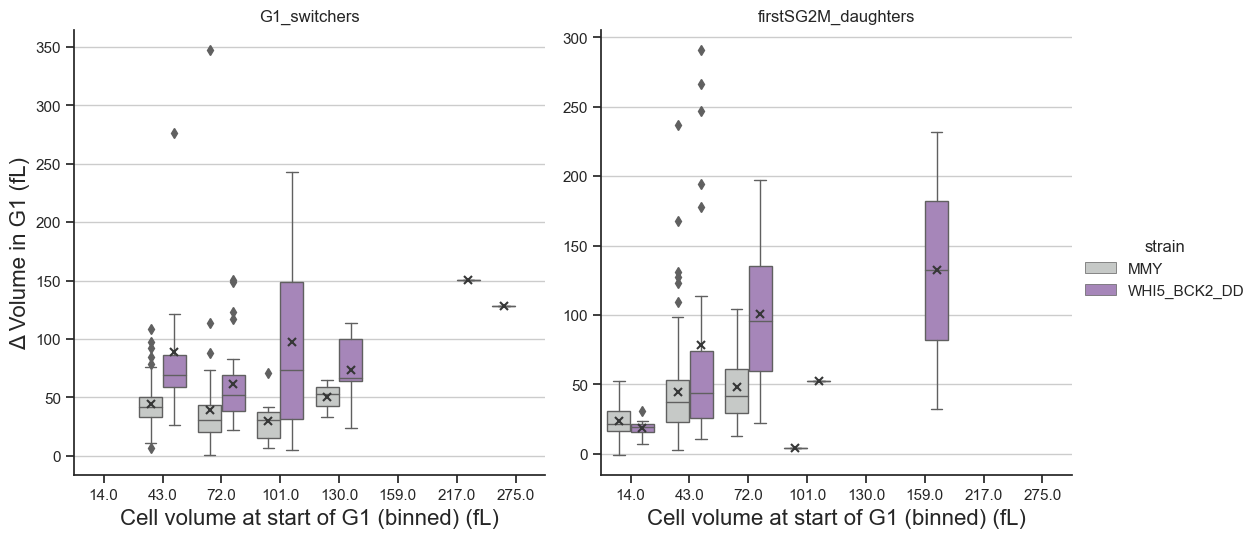

In [59]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.catplot(figure_plotting_df[(figure_plotting_df["plotting_col_ref"] == "G1_switchers") | 
                                    (figure_plotting_df["plotting_col_ref"] == "firstSG2M_daughters")], 
                kind = "box",
                x =  "bin_center",
                y = "phase_volume_growth",
                  col = "plotting_col_ref", 
                  col_order =[ 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 5.5,
                  col_wrap = 2,
                  sharey =False,
                  sharex = True,
                showmeans = True,
                meanprops={"marker":"x",
                      "markerfacecolor":None,
                      "markeredgecolor":"#363737",
                      "markersize":"6",
                      "markeredgewidth": 1.5},
                  # aspect  =1,
                  # margin_titles = True
                 )

# b.map_dataframe(sns.swarmplot,
#                 x =  "birth_vol_bin",
#                 y = "phase_volume_growth",
#                 hue = "strain",
#                   dodge = True,
#                   size = 1,
#                 palette = palette
#                   # margin_titles = True
#                  )



# b.map_dataframe(sns.barplot, 
#                 "birth_vol_bin",
#                 "phase_volume_growth", alpha = 0.5)
        



# # b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}")
# b.fig.subplots_adjust(top=0.9)
# # b.fig.suptitle("size control")
# b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
# b.set()
# b.add_legend()
# # ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Cell volume at start of G1 (binned) (fL)", "Δ Volume in G1 (fL)", fontsize = 16)
# # ax1.set_ylabel("G1 Length*Growth Rate")
# # ax1.set_ylim(-0.5,4)
# # ax1.set_xlim(2,6)
# #ax2.set_xscale("log")
# b.tick_params(axis='x', labelbottom=True)
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_sizecontrol_binned_categoryspecific_computer.png")
plt.savefig(r"C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_sizecontrol_binned_categoryspecific_computer.svg")





plt.show()

# ***not used - Revision1: mean cell vol vs frame_i for switchers and first daughters of S/G2/M switchers - WT and DD*** 

In [327]:

######################################### filter for steady state cells with complete G1s only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]
steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


C:\Users\Hp\AppData\Local\Temp\ipykernel_14152\2796781830.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


In [328]:
# display(overall_df_with_rel_and_switch_info.S_switch_cells_daughter_wave.dtype)

In [329]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      ]    
firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"
        

C:\Users\Hp\AppData\Local\Temp\ipykernel_14152\130744973.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"


In [330]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            ]
G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"        

C:\Users\Hp\AppData\Local\Temp\ipykernel_14152\3528487262.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"


In [331]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            ]
SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"    

C:\Users\Hp\AppData\Local\Temp\ipykernel_14152\3006354795.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"


In [332]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth

In [333]:


###############################################  steadystate  #####################################################################

SCD_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCD"]
SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
SCGE_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCGE"]
SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"

figure_plotting_df = pd.concat([SCD_steadystate_df, SCGE_steadystate_df, firstSG2M_daughters_df, G1_switchers_switchcycle_df, SG2M_switchers_switchcycle_df]).reset_index(drop = True)

figure_plotting_df['frame_rel_to_nutrient_switch'] = figure_plotting_df['frame_i'] - 50
figure_plotting_df['time_rel_to_nutrient_switch_hours'] = (figure_plotting_df['frame_rel_to_nutrient_switch']*3)/60

C:\Users\Hp\AppData\Local\Temp\ipykernel_14152\464224647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
C:\Users\Hp\AppData\Local\Temp\ipykernel_14152\464224647.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"


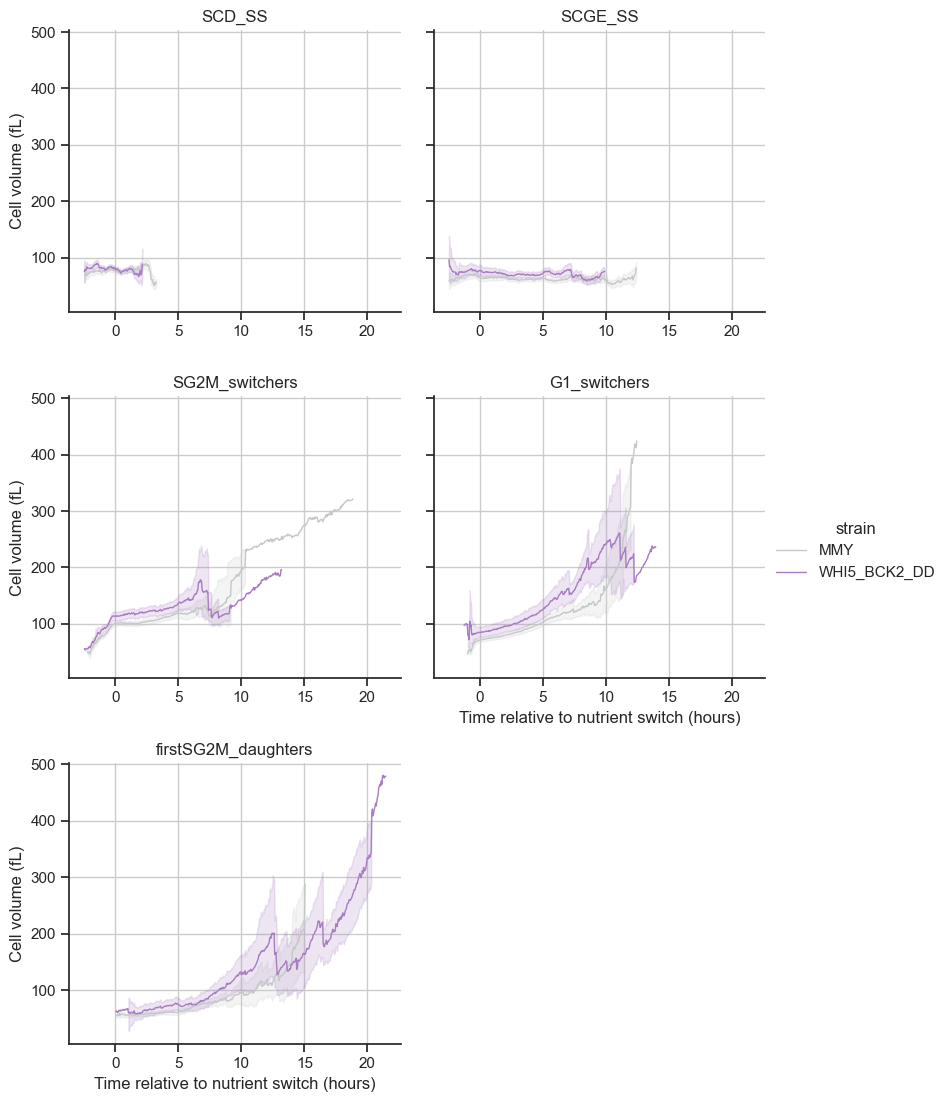

In [336]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#c5c9c7" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df, 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "combined_mother_bud_volume")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set()
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Cell volume (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")
# ax1.set_ylim(-0.5,4)
# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_mean_cell_vol_vs_time_categoryspecific.png')





plt.show()

# ***Revision1: delta vol since last frame normalised to cell vol at last frame vs frame_i for switchers and first daughters of S/G2/M switchers - WT and DD*** 

In [84]:
# old delta_vol_norm_cellvol column uses vol at current frame to normalise on. Recalculate by normalising on vol at prev frame. 

# display(overall_df_with_rel_and_switch_info.columns.tolist())
# display(overall_df_with_rel_and_switch_info[["f_pos_cell_id", "cell_cycle_stage", "frame_i", "cell_vol_fl", "cell_vol_fl_rel", "combined_mother_bud_volume", "vol_added_since_prev_frame_fl", "delta_vol_norm_cellvol"]].head(20))

overall_df_with_rel_and_switch_info['delta_vol_norm_cellvol'] = (overall_df_with_rel_and_switch_info['vol_added_since_prev_frame_fl'])/((overall_df_with_rel_and_switch_info['combined_mother_bud_volume']) - (overall_df_with_rel_and_switch_info['vol_added_since_prev_frame_fl']))
# overall_df_with_rel_and_switch_info.drop(columns = ["delta_vol_norm_cellvol_new"], inplace =True)
# display(overall_df_with_rel_and_switch_info[["f_pos_cell_id", "cell_cycle_stage", "frame_i", "cell_vol_fl", "cell_vol_fl_rel", "combined_mother_bud_volume", "vol_added_since_prev_frame_fl", "delta_vol_norm_cellvol"]].head(20))

In [85]:
# old delta_vol_norm_cellvol column uses vol at current frame to normalise on. Recalculate by normalising on vol at prev frame. 
# display(SS_SCDnSCGE.columns.tolist())
SS_SCDnSCGE['delta_vol_norm_cellvol'] = (SS_SCDnSCGE['vol_added_since_last_frame'])/((SS_SCDnSCGE['sys_vol_at_frame_inc_G1_cells']) - (SS_SCDnSCGE['vol_added_since_last_frame']))
# display(SS_SCDnSCGE[["f_pos_cell_id", "frame_i", "cell_vol_fl", "cell_cycle_stage", "rel_vol_atframe", "sys_vol_at_frame_inc_G1_cells", "vol_added_since_last_frame", "delta_vol_norm_cellvol"]].head(20))


In [86]:

######################################### filter for steady state cells with complete G1s only ##############################################

steady_state_completecycles_df =SS_SCDnSCGE[(SS_SCDnSCGE['complete_phase'] == 1)
                                          & (SS_SCDnSCGE['relationship'] != "bud")
                                          & ((SS_SCDnSCGE['strain'] == "MMY")|
                                            (SS_SCDnSCGE['strain'] == "WHI5_BCK2_DD"))
                                           ]
steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\2796781830.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  steady_state_completecycles_df.rename(columns={"sys_vol_at_frame_inc_G1_cells": "combined_mother_bud_volume"}, inplace = True)


In [87]:
# display(overall_df_with_rel_and_switch_info.S_switch_cells_daughter_wave.dtype)

In [88]:

## filter for nutrient switch first daughters of S/G2/M switchers with complete G1s only ##############################################
selectedstrains_NS_plotting_df = overall_df_with_rel_and_switch_info[(overall_df_with_rel_and_switch_info['strain'] == "MMY")|
                                                                    (overall_df_with_rel_and_switch_info['strain'] == "WHI5_BCK2_DD")
                                                                 ]
#display(selectedstrains_NS_plotting_df)
firstSG2M_daughters_df = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['S_switch_cells_daughter_wave'] == 1.0)
                                                      & ((selectedstrains_NS_plotting_df['post_switch_gen'] == 1)|
                                                        (selectedstrains_NS_plotting_df['post_switch_gen'] == "1.0"))
                                                      & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                      ]    
firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"
        

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\130744973.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firstSG2M_daughters_df['plotting_col_ref'] = "firstSG2M_daughters"


In [89]:

## filter for G1 switchers with complete G1s only ##############################################

G1_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_G1'] == True)
                                                            ]
G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"        

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3528487262.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  G1_switchers_switchcycle_df['plotting_col_ref'] = "G1_switchers"


In [90]:

## filter for S/G2/M switchers with complete G1s only ##############################################

SG2M_switchers_switchcycle_df  = selectedstrains_NS_plotting_df[(selectedstrains_NS_plotting_df['cycle_saw_switch'] == True) 
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_as_bud'] == False)
                                                            & (selectedstrains_NS_plotting_df['complete_phase'] == 1)
                                                            & (selectedstrains_NS_plotting_df['cell_saw_switch_in_S'] == True)
                                                            ]
SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"    

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3006354795.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SG2M_switchers_switchcycle_df['plotting_col_ref'] = "SG2M_switchers"


In [91]:
# display(overall_df_with_rel_and_switch_info.columns.tolist())
#vol_added_G1 phase_volume_growth

In [92]:


###############################################  steadystate  #####################################################################

SCD_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCD"]
SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
SCGE_steadystate_df = steady_state_completecycles_df[steady_state_completecycles_df['growthmedium'] == "SCGE"]
SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"

figure_plotting_df = pd.concat([SCD_steadystate_df, SCGE_steadystate_df, firstSG2M_daughters_df, G1_switchers_switchcycle_df, SG2M_switchers_switchcycle_df]).reset_index(drop = True)

figure_plotting_df['frame_rel_to_nutrient_switch'] = figure_plotting_df['frame_i'] - 50
figure_plotting_df['time_rel_to_nutrient_switch_hours'] = (figure_plotting_df['frame_rel_to_nutrient_switch']*3)/60

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\464224647.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCD_steadystate_df['plotting_col_ref'] = "SCD_SS"
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\464224647.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SCGE_steadystate_df['plotting_col_ref'] = "SCGE_SS"


C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


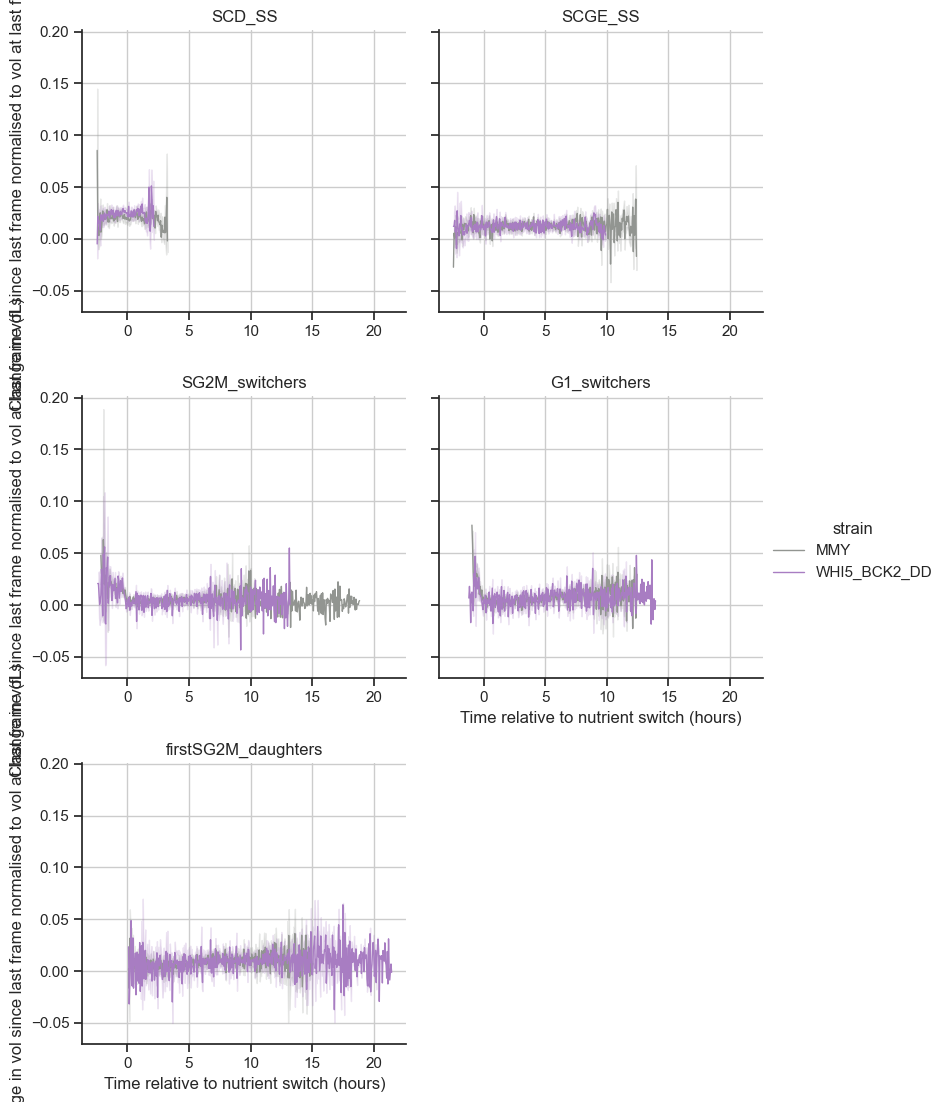

In [93]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df, 
                  col = "plotting_col_ref", 
                  col_order =['SCD_SS', 'SCGE_SS', 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  col_wrap = 2,
                  # sharey =False,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
# b.set(ylim = (-0.025,0.05))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Change in vol since last frame normalised to vol at last frame (fL)")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
# plt.savefig(r'D:\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\post_switch_normalised_delta_vol_vs_time_categoryspecific.png')





plt.show()

C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


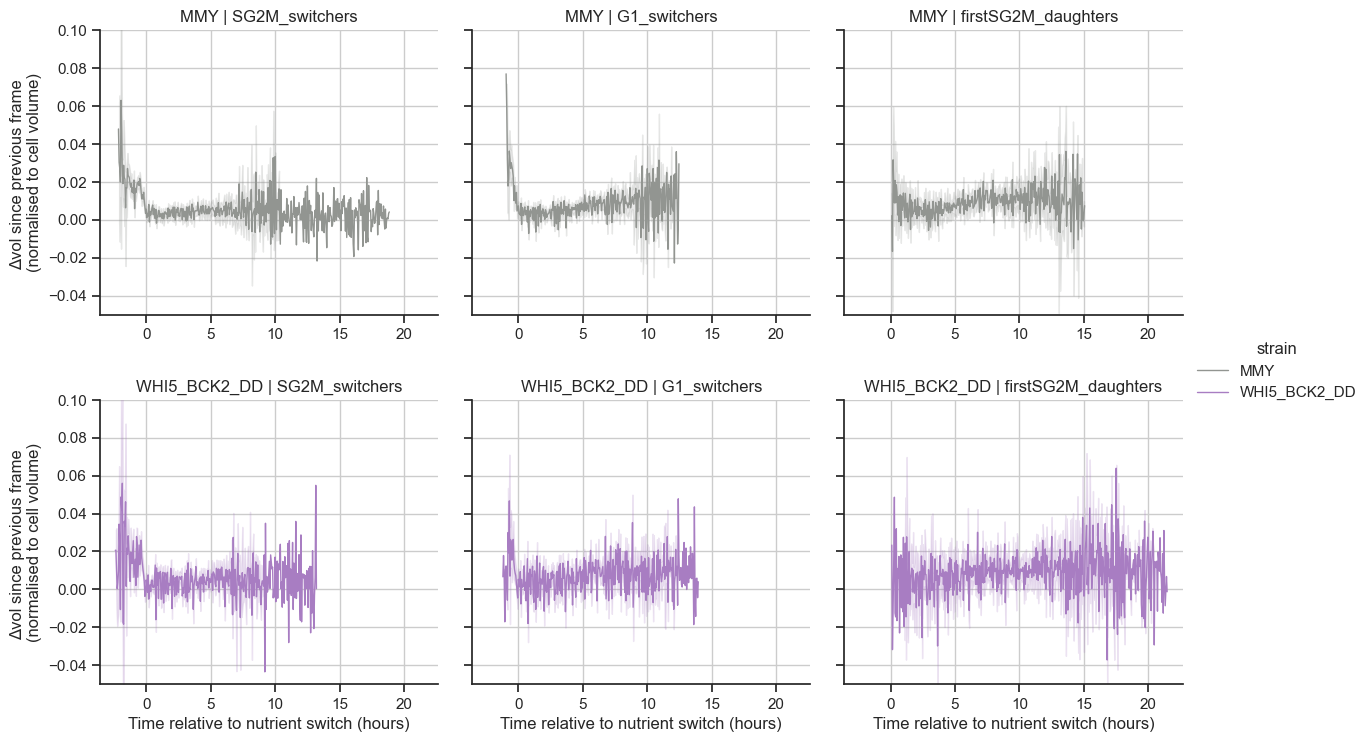

In [94]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df[(figure_plotting_df["plotting_col_ref"] == "G1_switchers") | 
                                      (figure_plotting_df["plotting_col_ref"] == "SG2M_switchers") |
                                    (figure_plotting_df["plotting_col_ref"] == "firstSG2M_daughters")], 
                  col = "plotting_col_ref", 
                  col_order =[ 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  row = "strain",
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  # col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.05,0.1))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Δvol since previous frame \n(normalised to cell volume)")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\inst_deltavol_norm_vs_time_original.png')
plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\inst_deltavol_norm_vs_time_original.svg')





plt.show()

In [95]:
appending_list = []
for category in figure_plotting_df['plotting_col_ref'].unique():
    category_df = figure_plotting_df[figure_plotting_df['plotting_col_ref'] == category]
    for strain in category_df['strain'].unique():
        strain_df = category_df[category_df['strain'] == strain]
        strain_df.sort_values(by = "frame_i", inplace=True)
        for frame in strain_df['frame_i'].unique():
            frame_df = strain_df[strain_df['frame_i'] == frame]
            time_rel_to_nutrient_switch_hours = frame_df['time_rel_to_nutrient_switch_hours'].iloc[0]
            frame_avg_deltavol_norm = frame_df['delta_vol_norm_cellvol'].mean()
            info = {'plotting_col_ref': category, 
                    'strain': strain,
                    'frame_i': frame,
                    'time_rel_to_nutrient_switch_hours': time_rel_to_nutrient_switch_hours,
                    'frame_avg_deltavol_norm': frame_avg_deltavol_norm
                    }
            appending_list.append(info)
                
figure_plotting_df_with_ma = pd.DataFrame.from_dict(appending_list)  

display(figure_plotting_df_with_ma.head(20))


C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3856238915.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df.sort_values(by = "frame_i", inplace=True)


,plotting_col_ref,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm
0,SCD_SS,MMY,1,-2.45,0.085246
1,SCD_SS,MMY,2,-2.40,0.013710
2,SCD_SS,MMY,3,-2.35,0.003676
3,SCD_SS,MMY,4,-2.30,0.003130
4,SCD_SS,MMY,5,-2.25,0.015546
5,SCD_SS,MMY,6,-2.20,0.024981
6,SCD_SS,MMY,7,-2.15,0.006359
7,SCD_SS,MMY,8,-2.10,0.011174
8,SCD_SS,MMY,9,-2.05,0.017674
9,SCD_SS,MMY,10,-2.00,0.026765


In [96]:
appending_list = []
for category in figure_plotting_df_with_ma['plotting_col_ref'].unique():
    category_df = figure_plotting_df_with_ma[figure_plotting_df_with_ma['plotting_col_ref'] == category]
    for strain in category_df['strain'].unique():
        strain_df = category_df[category_df['strain'] == strain]
        strain_df.sort_values(by = "frame_i", inplace=True)
        strain_df['moving_avg_delta_vol_norm_cellvol'] = strain_df['frame_avg_deltavol_norm'].rolling(10, min_periods = 3).mean()
        appending_list.append(strain_df)
figure_plotting_df_with_ma = pd.concat(appending_list).reset_index(drop= True)        
display(figure_plotting_df_with_ma.head(20))

C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3332681188.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df.sort_values(by = "frame_i", inplace=True)
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3332681188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strain_df['moving_avg_delta_vol_norm_cellvol'] = strain_df['frame_avg_deltavol_norm'].rolling(10, min_periods = 3).mean()
C:\Users\yagya.chadha\AppData\Local\Temp\ipykernel_10340\3332681188.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

,plotting_col_ref,strain,frame_i,time_rel_to_nutrient_switch_hours,frame_avg_deltavol_norm,moving_avg_delta_vol_norm_cellvol
0,SCD_SS,MMY,1,-2.45,0.085246,NaN
1,SCD_SS,MMY,2,-2.40,0.013710,NaN
2,SCD_SS,MMY,3,-2.35,0.003676,0.034211
3,SCD_SS,MMY,4,-2.30,0.003130,0.026440
4,SCD_SS,MMY,5,-2.25,0.015546,0.024262
5,SCD_SS,MMY,6,-2.20,0.024981,0.024381
6,SCD_SS,MMY,7,-2.15,0.006359,0.021807
7,SCD_SS,MMY,8,-2.10,0.011174,0.020478
8,SCD_SS,MMY,9,-2.05,0.017674,0.020166
9,SCD_SS,MMY,10,-2.00,0.026765,0.020826


C:\Users\yagya.chadha\.conda\envs\acdc_new\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


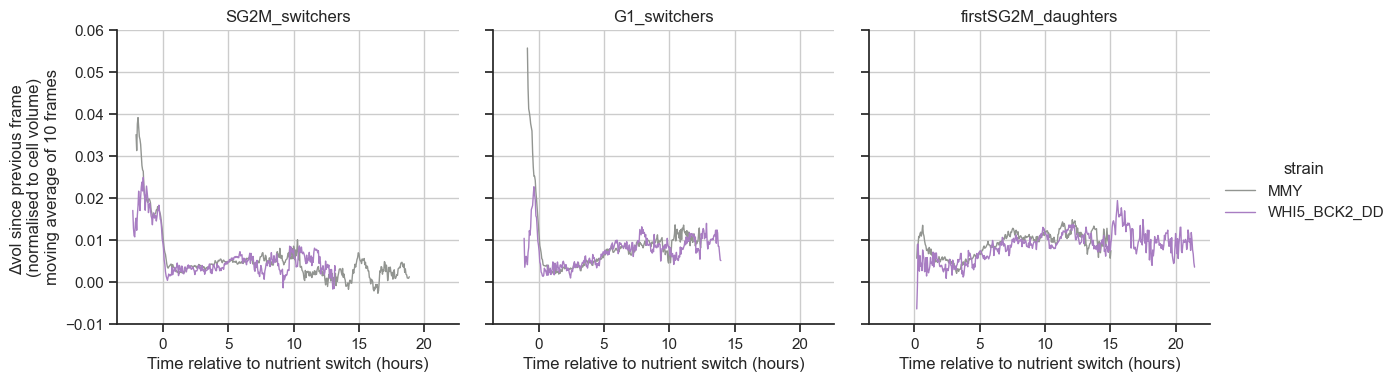

In [97]:
sns.set_context("notebook", rc={"lines.linewidth": 1.0})
sns.set_style("ticks",{'axes.grid' : True})

palette ={"MMY":"#929591" , "WHI5DEL": "#c87f89", "BCK2DEL": "#5684ae", "WHI5_BCK2_DD":"#a87dc2"}

# def annotate(data, **kws):
#         ax = plt.gca()
#         slope, intercept, r_value, p_value, std_err = stats.linregress(x=ax.get_lines()[0].get_xdata(),y=ax.get_lines()[0].get_ydata())
#         ax.text(0.5, 0.9, f"y = {slope:.2f} x + {intercept:.1f}",
#                 horizontalalignment='center',
#                 verticalalignment='center',
#                 transform=ax.transAxes)
#         #display(ax,slope, intercept, r_value, p_value, std_err)

b = sns.FacetGrid(figure_plotting_df_with_ma[(figure_plotting_df_with_ma["plotting_col_ref"] == "G1_switchers") | 
                                      (figure_plotting_df_with_ma["plotting_col_ref"] == "SG2M_switchers") |
                                    (figure_plotting_df_with_ma["plotting_col_ref"] == "firstSG2M_daughters")], 
                  col = "plotting_col_ref", 
                  col_order =[ 'SG2M_switchers', 'G1_switchers','firstSG2M_daughters'],
                  hue = "strain", 
                  # row = "strain",
                  palette = palette,
                  height = 4,
                  # legend_out = True,
                  # col_wrap = 2,
                  sharey =True,
                  sharex = True
                  # aspect  =1,
                  # margin_titles = True
                 )


b.map_dataframe(sns.lineplot, 
      "time_rel_to_nutrient_switch_hours",
      "moving_avg_delta_vol_norm_cellvol")


# b.map_dataframe(annotate)
b.set_titles(col_template="{col_name}", row_template="{row_name}")
b.fig.subplots_adjust(top=0.9)
# b.fig.suptitle("size control")
b.figure.subplots_adjust(wspace=0.1, hspace=0.3)
b.set(ylim = (-0.01,0.06))
b.add_legend()
# ax1.set_title("SCD steady state daughters")
b.set_axis_labels("Time relative to nutrient switch (hours)", "Δvol since previous frame \n(normalised to cell volume)\nmoving average of 10 frames")
# ax1.set_ylabel("G1 Length*Growth Rate")

# ax1.set_xlim(2,6)
#ax2.set_xscale("log")
b.tick_params(axis='x', labelbottom=True)
plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\moving_avg_inst_deltavol_norm_vs_time.png')
plt.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Literature\nutrient switch paper 2024\JCB revision 1\postswitch_CV_plots\moving_avg_inst_deltavol_norm_vs_time.svg')





plt.show()